# Module 4B — Transformer Optimization (Beginner Expanded)
## RoPE kernels, LayerNorm + GELU fusion, and memory-efficient attention patterns

This notebook is an expanded, beginner-friendly edition of the attached Module 4B notebook.

### What I preserved
Per your instruction, the **original code cells from the attached notebook are kept unchanged** unless a change is absolutely necessary.  
In this expansion, I **did not rewrite the original code cells**. Instead, I added:

- more beginner-oriented explanations,
- more intuition before formulas,
- extra examples,
- a few optional GPU benchmark cells with strong comments and safety guards,
- and more interview-oriented framing.

### One provenance note
The attached notebook's original internal title says **"Module 4A"**, but its content clearly matches your Module 4B topics:

- RoPE optimization,
- fused LayerNorm + GELU,
- memory-efficient attention patterns.

I keep the original source content intact for provenance, and I use this wrapper title so the notebook is self-explanatory.


## How to read this notebook if you are a beginner

A beginner often gets overwhelmed because these topics mix **math**, **GPU programming**, and **system design**.

A better reading order is:

1. **Understand the idea first.**  
   Ask: *What mathematical operation is happening?*

2. **Understand the bottleneck second.**  
   Ask: *Why is this operation slow on a GPU?*  
   The answer is often: **too much memory movement**.

3. **Understand the kernel mapping third.**  
   Ask: *Which thread does which piece of work?*

4. **Understand the system implication fourth.**  
   Ask: *Why does this matter for LLM training or inference latency?*

That is the recurring pattern in this notebook:

- **RoPE:** a small rotation mathematically, but applied to huge tensors.
- **LayerNorm + GELU:** simple operations, but repeated in every block.
- **Attention memory:** the operator is elegant mathematically, but the memory footprint can dominate the system.

A good interview answer almost always moves through those same four levels.



# Module 4A — Transformer Optimization for LLM Training and Inference
## RoPE kernels, LayerNorm + GELU fusion, and memory-efficient attention patterns

This notebook is designed as a **study + coding lab** for interview preparation in **LLM training / inference / AI infrastructure**. It emphasizes three ideas that repeatedly appear in strong systems interviews:

1. **Move less data** between HBM and on-chip memory.
2. **Fuse operations** so intermediate tensors are not written out and read back.
3. **Know the memory math** for attention, KV cache growth, and sequence-length scaling.

### Learning objectives
- Build custom GPU kernels for **RoPE**, **LayerNorm**, and **GELU**.
- Understand why **LayerNorm + GELU fusion** reduces memory traffic.
- Analyze **attention memory usage** and the trade-offs behind FlashAttention, SDPA, GQA/MQA, checkpointing, and paged KV caches.
- Prepare concise, technically correct explanations for **LLM systems interviews**.

### Authoritative source map used for these notes
Primary papers and official documentation that inform this notebook:
- Vaswani et al., **Attention Is All You Need** (2017).
- Su et al., **RoFormer: Enhanced Transformer with Rotary Position Embedding** (2021).
- Ba, Kiros, Hinton, **Layer Normalization** (2016).
- Hendrycks, Gimpel, **Gaussian Error Linear Units (GELUs)** (2016).
- Dao et al., **FlashAttention** (2022).
- Dao, **FlashAttention-2** (2023).
- Shazeer, **Fast Transformer Decoding: One Write-Head is All You Need** (MQA, 2019).
- Ainslie et al., **GQA: Training Generalized Multi-Query Transformer Models** (2023).
- Kwon et al., **PagedAttention / vLLM** (2023).
- Official **PyTorch SDPA** tutorial and docs.
- Official **NVIDIA CUDA C++ Programming Guide** and **Best Practices Guide**.

### How to use this notebook
- On **Google Colab** or your **HP OmniDesk + RTX 5060**, the optional GPU sections can run on real CUDA.
- On a machine **without a CUDA runtime**, the notebook automatically enables the **Numba CUDA simulator** so the kernels are still logically validated.
- The CUDA kernels here are **educational kernels**, not state-of-the-art production kernels. The goal is to learn the right design principles and verify correctness.


In [1]:

# Environment bootstrap.
# This cell is intentionally detailed because it is the first thing an interviewer or a teammate
# would check when trying to reproduce your experiments.

import os
import math
import time
import random
import importlib.util

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Make plots readable in both GitHub notebook previews and VS Code.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

# Fix random seeds for deterministic, repeatable toy experiments.
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Decide whether to use a real CUDA device or Numba's CPU-side CUDA simulator.
# The simulator is very useful for correctness testing when a GPU is not available.
HAS_TORCH_CUDA = torch.cuda.is_available()
if not HAS_TORCH_CUDA:
    os.environ.setdefault("NUMBA_ENABLE_CUDASIM", "1")

from numba import cuda, float32  # Imported only after the simulator decision above.

USING_CUDA_SIMULATOR = os.environ.get("NUMBA_ENABLE_CUDASIM", "0") == "1"

print("Torch version:", torch.__version__)
print("Torch CUDA available:", HAS_TORCH_CUDA)
if HAS_TORCH_CUDA:
    print("Torch CUDA device:", torch.cuda.get_device_name(0))
print("Using Numba CUDA simulator:", USING_CUDA_SIMULATOR)
print("Numba CUDA available:", cuda.is_available())


Torch version: 2.10.0+cpu
Torch CUDA available: False
Using Numba CUDA simulator: True
Numba CUDA available: True


## Beginner mental model: what the GPU is trying to protect you from

A useful simplification is:

| Memory level | Very rough role | Relative speed | Relative size | Why you care |
|---|---|---:|---:|---|
| **Registers** | per-thread scratchpad | fastest | tiniest | best place to keep values currently being computed |
| **Shared memory / SRAM** | small on-chip memory shared by threads in a block | very fast | small | great for reuse and reductions |
| **HBM / global memory** | large off-chip GPU memory | much slower than on-chip memory | large | every unnecessary read/write hurts |

The most important optimization theme in this notebook is:

> **Do more useful work per byte fetched from HBM.**

That is why the same vocabulary keeps coming back:

- **coalesced access**
- **tiling**
- **reuse**
- **fusion**
- **avoid materialization**
- **FP32 accumulation where needed**
- **validate correctness before benchmarking**



## 1. Why these topics matter in real LLM systems

In modern transformers, the dominant performance limit is often **memory movement**, not raw FLOPs.

### The key bottlenecks
- **RoPE** is applied to large Q/K tensors every forward pass. Poor implementations waste bandwidth.
- **LayerNorm + GELU** appear in every block. If you launch multiple kernels and materialize intermediates, you pay avoidable HBM traffic.
- **Attention memory** scales badly with sequence length if you materialize full score/probability tensors.
- **KV cache memory** grows linearly with generated tokens and can become the serving bottleneck.

### The mental model interviewers want
When asked how to optimize a transformer, a strong answer sounds like this:

> "First I identify whether the layer is compute-bound or bandwidth-bound. Then I reduce global memory traffic through tiling, fusion, vectorized/coalesced access, reuse in shared memory or registers, and by avoiding materialization of large intermediate tensors."

That sentence connects directly to RoPE kernels, fused LayerNorm/GELU, FlashAttention, GQA/MQA, and paged KV caches.


In [2]:

# Utility helpers used throughout the notebook.

BYTES_PER_FP16 = 2
BYTES_PER_BF16 = 2
BYTES_PER_FP32 = 4


def bytes_to_mib(num_bytes: float) -> float:
    """Convert bytes to MiB for human-readable memory reporting."""
    return num_bytes / (1024 ** 2)


def bytes_to_gib(num_bytes: float) -> float:
    """Convert bytes to GiB for human-readable memory reporting."""
    return num_bytes / (1024 ** 3)


def estimate_attention_score_bytes(batch_size: int, num_heads: int, seq_len: int, dtype_bytes: int = BYTES_PER_BF16) -> int:
    """
    Estimate the size of one fully materialized attention score tensor of shape [B, H, N, N].

    This is the memory for a *single* score matrix. Real implementations may also materialize
    probabilities, masks, dropout states, or backward buffers, which can increase the footprint.
    """
    return batch_size * num_heads * seq_len * seq_len * dtype_bytes



def estimate_local_attention_score_bytes(batch_size: int, num_heads: int, seq_len: int, window: int, dtype_bytes: int = BYTES_PER_BF16) -> int:
    """
    Estimate score storage for local/sliding-window attention if a width-W band is materialized.
    This scales as O(B * H * N * W) instead of O(B * H * N^2).
    """
    return batch_size * num_heads * seq_len * window * dtype_bytes



def estimate_kv_cache_bytes(num_layers: int, batch_size: int, seq_len: int, num_kv_heads: int, head_dim: int, dtype_bytes: int = BYTES_PER_BF16) -> int:
    """
    KV cache memory for autoregressive decoding.

    Formula:
        2 * L * B * T * H_kv * D_head * bytes

    The factor 2 appears because we store both keys and values.
    """
    return 2 * num_layers * batch_size * seq_len * num_kv_heads * head_dim * dtype_bytes


## Before RoPE: the intuition in plain language

RoPE can feel abstract on first read, so here is the simplest picture.

Take a hidden vector and group it into pairs:

$$
(x_0, x_1), (x_2, x_3), (x_4, x_5), \dots
$$

Each pair behaves like a tiny 2D vector.  
For each token position, RoPE rotates each 2D pair by a position-dependent angle.

So the mental model is:

- **same vector length**
- **different angle**
- **different frequency band for different pairs**

This is why people often say RoPE behaves like a collection of tiny position-dependent rotations.

Two beginner takeaways matter most:

1. **RoPE preserves the norm of each 2D pair.**  
   A rotation changes direction, not length.

2. **RoPE injects relative position structure into attention.**  
   That is why it is more than just a cosmetic transformation.



## 2. Rotary Position Embeddings (RoPE)

### Core idea
RoPE rotates each even/odd pair of channels by a position-dependent angle. If a token vector is split into 2D pairs,

$$
(x_{2i}, x_{2i+1}) \mapsto
\begin{bmatrix}
\cos \theta_{p,i} & -\sin \theta_{p,i} \\
\sin \theta_{p,i} & \cos \theta_{p,i}
\end{bmatrix}
\begin{bmatrix}
 x_{2i} \\
 x_{2i+1}
\end{bmatrix}
$$

where $p$ is the position and $i$ indexes a frequency band.

### Why RoPE is attractive
- It injects position using **rotations** rather than additive embeddings.
- It preserves the **2D norm** of each rotated pair.
- In the attention dot product, RoPE naturally encodes **relative position structure**.

### Optimization principles for RoPE
A strong implementation usually does the following:
- **Precompute** the cosine/sine cache once for the max sequence length.
- Rotate **Q and K only**, not V.
- Load/store the even/odd pair together when possible.
- Avoid launching extra kernels for temporary tensors.
- Keep indexing simple and contiguous to help **coalesced memory access**.


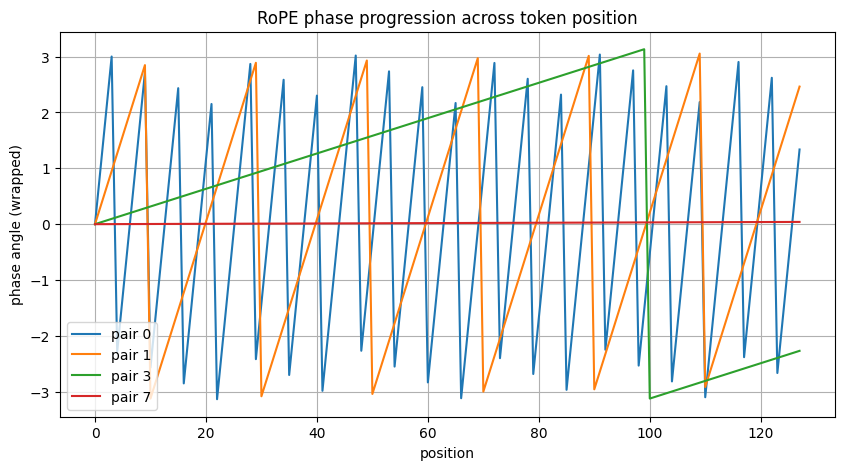

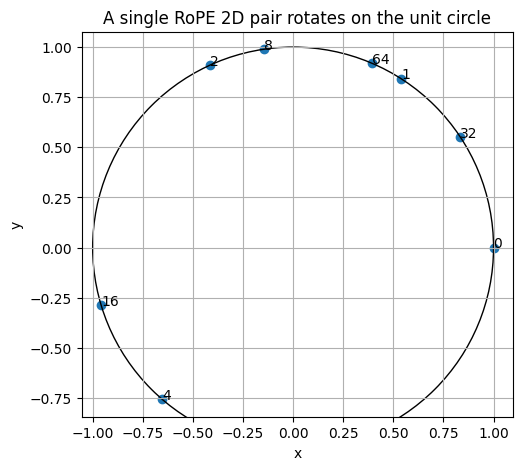

Max pairwise norm error after RoPE: 9.5367431640625e-07


In [3]:

# Reference RoPE implementation + visual intuition.
# This is the ground truth used to validate the CUDA kernel later.


def build_rope_cache(seq_len: int, dim: int, base: float = 10000.0, dtype=np.float32):
    """
    Build the cosine/sine cache for RoPE.

    Parameters
    ----------
    seq_len : int
        Maximum sequence length.
    dim : int
        Full hidden dimension. Must be even because RoPE rotates pairs.
    base : float
        Standard RoPE base from the RoFormer formulation.
    dtype : numpy dtype
        Storage dtype for the cache.
    """
    assert dim % 2 == 0, "RoPE requires an even hidden dimension."
    half_dim = dim // 2
    inv_freq = 1.0 / (base ** (np.arange(0, half_dim, dtype=np.float64) / half_dim))
    positions = np.arange(seq_len, dtype=np.float64)[:, None]
    angles = positions * inv_freq[None, :]
    return np.cos(angles).astype(dtype), np.sin(angles).astype(dtype)



def apply_rope_reference(x: np.ndarray, positions: np.ndarray, cos_cache: np.ndarray, sin_cache: np.ndarray) -> np.ndarray:
    """
    Apply RoPE to a [num_tokens, dim] matrix using a reference NumPy implementation.

    This function is deliberately clear rather than micro-optimized.
    """
    num_tokens, dim = x.shape
    half_dim = dim // 2
    out = np.empty_like(x)
    for token in range(num_tokens):
        pos = positions[token]
        for pair in range(half_dim):
            x0 = x[token, 2 * pair]
            x1 = x[token, 2 * pair + 1]
            c = cos_cache[pos, pair]
            s = sin_cache[pos, pair]
            out[token, 2 * pair] = x0 * c - x1 * s
            out[token, 2 * pair + 1] = x0 * s + x1 * c
    return out


# Small demonstration setup.
rope_dim = 16
rope_seq = 128
cos_cache, sin_cache = build_rope_cache(seq_len=rope_seq, dim=rope_dim)

# Plot how rotation angles evolve over position for a few frequency bands.
positions = np.arange(rope_seq)
fig, ax = plt.subplots()
for pair_idx in [0, 1, 3, 7]:
    angles = np.arctan2(sin_cache[:, pair_idx], cos_cache[:, pair_idx])
    ax.plot(positions, angles, label=f"pair {pair_idx}")
ax.set_title("RoPE phase progression across token position")
ax.set_xlabel("position")
ax.set_ylabel("phase angle (wrapped)")
ax.legend()
plt.show()

# Visualize one 2D pair rotating on the unit circle across several positions.
fig, ax = plt.subplots()
unit_pair = np.array([1.0, 0.0], dtype=np.float32)
selected_positions = [0, 1, 2, 4, 8, 16, 32, 64]
coords_x, coords_y = [], []
for pos in selected_positions:
    c = cos_cache[pos, 0]
    s = sin_cache[pos, 0]
    rotated = np.array([unit_pair[0] * c - unit_pair[1] * s, unit_pair[0] * s + unit_pair[1] * c])
    coords_x.append(rotated[0])
    coords_y.append(rotated[1])
ax.scatter(coords_x, coords_y)
for x_coord, y_coord, pos in zip(coords_x, coords_y, selected_positions):
    ax.annotate(str(pos), (x_coord, y_coord))
unit_circle = plt.Circle((0, 0), 1.0, fill=False)
ax.add_artist(unit_circle)
ax.set_aspect("equal")
ax.set_title("A single RoPE 2D pair rotates on the unit circle")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

# Validate the norm-preserving property pair by pair.
x_demo = np.random.randn(6, rope_dim).astype(np.float32)
pos_demo = np.arange(6, dtype=np.int32)
y_demo = apply_rope_reference(x_demo, pos_demo, cos_cache, sin_cache)

pairwise_norm_before = (x_demo[:, 0::2] ** 2 + x_demo[:, 1::2] ** 2)
pairwise_norm_after = (y_demo[:, 0::2] ** 2 + y_demo[:, 1::2] ** 2)
max_pairwise_norm_error = np.max(np.abs(pairwise_norm_before - pairwise_norm_after))
print("Max pairwise norm error after RoPE:", float(max_pairwise_norm_error))
assert max_pairwise_norm_error < 1e-5


RoPE norm preservation check
position= 0  before_norm=1.581139  after_norm=1.581139
position= 4  before_norm=1.581139  after_norm=1.581139
position= 8  before_norm=1.581139  after_norm=1.581139
position=12  before_norm=1.581139  after_norm=1.581139
position=16  before_norm=1.581139  after_norm=1.581139


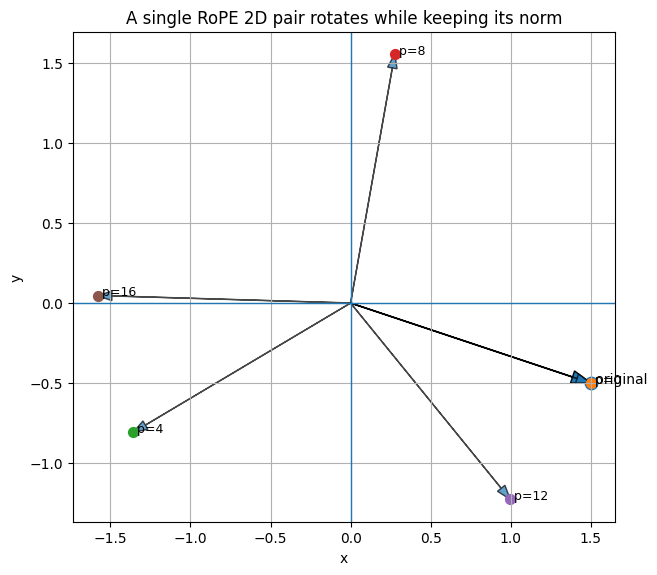

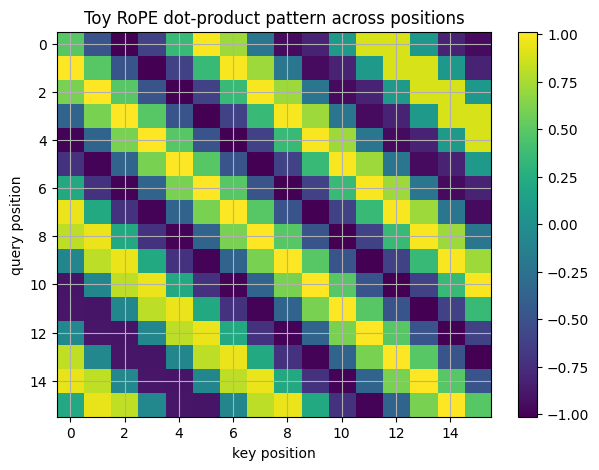

Interpretation:
- The heatmap is not random noise.
- RoPE changes scores in a structured way as positions change.
- This is the beginner intuition behind the statement that RoPE carries relative-position information.


In [4]:
# Extra beginner example: RoPE as a geometric rotation.
# This cell is deliberately educational. It shows two things:
# 1) A rotated 2D pair keeps the same length.
# 2) The RoPE-modified dot-product pattern depends on relative position.

# Part A: norm preservation
pair = np.array([[1.5, -0.5]], dtype=np.float32)
demo_positions = np.array([0, 4, 8, 12, 16], dtype=np.int32)
cos_small, sin_small = build_rope_cache(seq_len=int(demo_positions.max()) + 1, dim=2)
pair_tiled = np.repeat(pair, len(demo_positions), axis=0)
pair_rot = apply_rope_reference(pair_tiled, demo_positions, cos_small, sin_small)
before_norm = np.linalg.norm(pair_tiled, axis=1)
after_norm = np.linalg.norm(pair_rot, axis=1)

print("RoPE norm preservation check")
for p, bn, an in zip(demo_positions, before_norm, after_norm):
    print(f"position={int(p):2d}  before_norm={bn:.6f}  after_norm={an:.6f}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.axhline(0.0, linewidth=1)
ax.axvline(0.0, linewidth=1)
ax.arrow(0, 0, pair[0, 0], pair[0, 1], head_width=0.08, length_includes_head=True)
ax.scatter([pair[0, 0]], [pair[0, 1]], s=80)
ax.text(pair[0, 0], pair[0, 1], " original", fontsize=10)
for p, vec in zip(demo_positions, pair_rot):
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.06, length_includes_head=True, alpha=0.7)
    ax.scatter([vec[0]], [vec[1]], s=50)
    ax.text(vec[0], vec[1], f" p={int(p)}", fontsize=9)
ax.set_title("A single RoPE 2D pair rotates while keeping its norm")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.show()

# Part B: relative-position intuition
base_q = np.array([[1.0, 0.2]], dtype=np.float32)
base_k = np.array([[0.3, 0.95]], dtype=np.float32)
pos_ids = np.arange(16, dtype=np.int32)
cos_rel, sin_rel = build_rope_cache(seq_len=int(pos_ids.max()) + 1, dim=2)
rot_q = apply_rope_reference(np.repeat(base_q, len(pos_ids), axis=0), pos_ids, cos_rel, sin_rel)
rot_k = apply_rope_reference(np.repeat(base_k, len(pos_ids), axis=0), pos_ids, cos_rel, sin_rel)
score_matrix = rot_q @ rot_k.T

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(score_matrix, aspect="auto")
ax.set_title("Toy RoPE dot-product pattern across positions")
ax.set_xlabel("key position")
ax.set_ylabel("query position")
plt.colorbar(im, ax=ax)
plt.show()

print("Interpretation:")
print("- The heatmap is not random noise.")
print("- RoPE changes scores in a structured way as positions change.")
print("- This is the beginner intuition behind the statement that RoPE carries relative-position information.")



### CUDA kernel design for RoPE

A practical RoPE kernel usually maps one thread to one rotated pair `(even, odd)`.

#### Design choices
- **Thread mapping:** thread `idx` handles `(token, pair)`.
- **Reads:** one pair from `x`, one pair `(cos, sin)` from the cache.
- **Writes:** one rotated pair to `out`.
- **Arithmetic:** four multiply-add style operations per pair.

#### Interview-ready explanation
If someone asks how to optimize RoPE, a good answer is:

> "I would precompute the angle cache, use contiguous pairwise access, rotate Q/K in-place or into a single output buffer, and avoid a separate permutation step. RoPE is bandwidth-sensitive because the arithmetic per element is small compared with the tensor movement."


## What one RoPE CUDA thread is really doing

It helps to narrate the kernel in human language.

Suppose one thread is responsible for one `(token, pair)`.

That thread does exactly this:

1. Figure out **which token** and **which pair** it owns.
2. Read two numbers from the input tensor:
   - the **even** channel,
   - the **odd** channel.
3. Read two numbers from the cache:
   - `cos(theta)`,
   - `sin(theta)`.
4. Apply the 2D rotation formula.
5. Write the rotated pair to the output.

That is a small amount of arithmetic relative to the amount of data touched, which is why the operation is often **bandwidth-sensitive**.

A beginner rule of thumb:

> If an operation touches a lot of tensor elements but does not do much arithmetic per element, start by suspecting a **memory-bandwidth bottleneck**.


In [5]:

# Custom CUDA kernel for RoPE using Numba.
# This is an educational kernel that is easy to read and validate.

@cuda.jit
def rope_cuda_kernel(x, positions, cos_cache, sin_cache, out):
    """
    Apply RoPE to a [num_tokens, dim] tensor.

    x          : float32[num_tokens, dim]
    positions  : int32[num_tokens]
    cos_cache  : float32[max_seq_len, dim//2]
    sin_cache  : float32[max_seq_len, dim//2]
    out        : float32[num_tokens, dim]

    One thread handles one even/odd pair.
    """
    idx = cuda.grid(1)
    num_tokens = x.shape[0]
    dim = x.shape[1]
    half_dim = dim // 2
    total_pairs = num_tokens * half_dim

    if idx < total_pairs:
        token = idx // half_dim
        pair = idx % half_dim
        pos = positions[token]

        x0 = x[token, 2 * pair]
        x1 = x[token, 2 * pair + 1]
        c = cos_cache[pos, pair]
        s = sin_cache[pos, pair]

        out[token, 2 * pair] = x0 * c - x1 * s
        out[token, 2 * pair + 1] = x0 * s + x1 * c


# Validate the kernel against the NumPy reference.
num_tokens = 32
dim = 64
max_seq_len = 128
x = np.random.randn(num_tokens, dim).astype(np.float32)
positions = np.random.randint(0, max_seq_len, size=(num_tokens,), dtype=np.int32)
cos_cache, sin_cache = build_rope_cache(seq_len=max_seq_len, dim=dim)
reference = apply_rope_reference(x, positions, cos_cache, sin_cache)

x_d = cuda.to_device(x)
pos_d = cuda.to_device(positions)
cos_d = cuda.to_device(cos_cache)
sin_d = cuda.to_device(sin_cache)
out_d = cuda.device_array_like(x_d)

threads_per_block = 128
total_pairs = num_tokens * (dim // 2)
blocks_per_grid = (total_pairs + threads_per_block - 1) // threads_per_block
rope_cuda_kernel[blocks_per_grid, threads_per_block](x_d, pos_d, cos_d, sin_d, out_d)
out = out_d.copy_to_host()

rope_max_error = np.max(np.abs(out - reference))
print("RoPE kernel max abs error:", float(rope_max_error))
assert rope_max_error < 1e-5


RoPE kernel max abs error: 0.0


In [6]:
# Optional real-GPU benchmark: measure the educational RoPE CUDA kernel on a real CUDA device.
# This cell is intentionally guarded so it is safe in CPU-only environments or when the notebook
# is using the Numba CUDA simulator.

if not HAS_TORCH_CUDA or USING_CUDA_SIMULATOR:
    print("Skipping real-GPU RoPE benchmark because no real CUDA device is active in this runtime.")
else:
    num_tokens_bench = 4096
    dim_bench = 128
    max_seq_bench = 4096
    iters = 20

    x_bench = np.random.randn(num_tokens_bench, dim_bench).astype(np.float32)
    pos_bench = np.random.randint(0, max_seq_bench, size=(num_tokens_bench,), dtype=np.int32)
    cos_bench, sin_bench = build_rope_cache(seq_len=max_seq_bench, dim=dim_bench)

    x_bench_d = cuda.to_device(x_bench)
    pos_bench_d = cuda.to_device(pos_bench)
    cos_bench_d = cuda.to_device(cos_bench)
    sin_bench_d = cuda.to_device(sin_bench)
    out_bench_d = cuda.device_array_like(x_bench_d)

    threads_per_block = 128
    total_pairs = num_tokens_bench * (dim_bench // 2)
    blocks_per_grid = (total_pairs + threads_per_block - 1) // threads_per_block

    for _ in range(3):
        rope_cuda_kernel[blocks_per_grid, threads_per_block](x_bench_d, pos_bench_d, cos_bench_d, sin_bench_d, out_bench_d)
    cuda.synchronize()

    start = time.perf_counter()
    for _ in range(iters):
        rope_cuda_kernel[blocks_per_grid, threads_per_block](x_bench_d, pos_bench_d, cos_bench_d, sin_bench_d, out_bench_d)
    cuda.synchronize()
    elapsed_s = time.perf_counter() - start

    avg_ms = 1000.0 * elapsed_s / iters
    bytes_per_pair = 24
    approx_total_bytes = total_pairs * bytes_per_pair
    approx_gbps = (approx_total_bytes / (avg_ms / 1000.0)) / 1e9

    print(f"RoPE benchmark average time: {avg_ms:.3f} ms")
    print(f"Approximate effective bandwidth: {approx_gbps:.2f} GB/s")
    print("\nHow to interpret this:")
    print("- This is an educational estimate, not a formal roofline analysis.")
    print("- The point is to connect kernel runtime to bytes moved.")
    print("- If the kernel is bandwidth-sensitive, reducing memory traffic often matters more than adding math tricks.")


Skipping real-GPU RoPE benchmark because no real CUDA device is active in this runtime.


## Before LayerNorm + GELU: what these two operators do conceptually

Beginners often remember the formulas but miss the roles.

### LayerNorm
LayerNorm says:

> "Within one token representation, normalize the hidden features so their scale is more controlled."

So the intuition is:

- subtract the row mean,
- divide by the row standard deviation,
- then apply learned scale and bias.

It is a **row-wise stabilization step**.

### GELU
GELU is a smooth nonlinearity.  
Unlike ReLU, which hard-clips negative values to zero, GELU smoothly downweights them.

So the intuition is:

- **large positive values** mostly pass through,
- **large negative values** are strongly suppressed,
- **near-zero values** are treated smoothly rather than abruptly.

### Why the pair matters in transformers
A very common pattern is:

1. normalize,
2. do an affine transform or projection,
3. apply a nonlinearity.

Because these steps happen so often, even modest per-layer inefficiencies become very expensive across dozens of layers and long sequences.



## 3. LayerNorm and GELU: why fusion matters

### LayerNorm recap
For a row vector $x \in \mathbb{R}^d$,

$$
\mu = \frac{1}{d} \sum_{i=1}^{d} x_i,
\qquad
\sigma^2 = \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2,
$$

$$
\text{LayerNorm}(x)_i = \gamma_i \cdot \frac{x_i - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta_i.
$$

### GELU recap
The original GELU is

$$
\text{GELU}(x) = x\,\Phi(x),
$$

and a common fast approximation is

$$
\text{GELU}(x) \approx 0.5x\left(1 + \tanh\left(\sqrt{\frac{2}{\pi}}(x + 0.044715x^3)\right)\right).
$$

### Why fuse LayerNorm + GELU?
If you do them as two separate kernels:
1. Read the input row.
2. Compute LayerNorm.
3. **Write an intermediate tensor** to global memory.
4. Launch another kernel.
5. Read that intermediate tensor back.
6. Apply GELU.
7. Write the final output.

A fused kernel removes the **intermediate write + read round-trip**, which often matters more than the saved arithmetic.

### What production kernels usually do
- Accumulate mean/variance in **FP32**.
- Use **shared memory** or warp shuffles for reduction.
- Keep one block per row or one warp per row depending on hidden size.
- Fuse affine transform and GELU while the values are still hot in registers/shared memory.


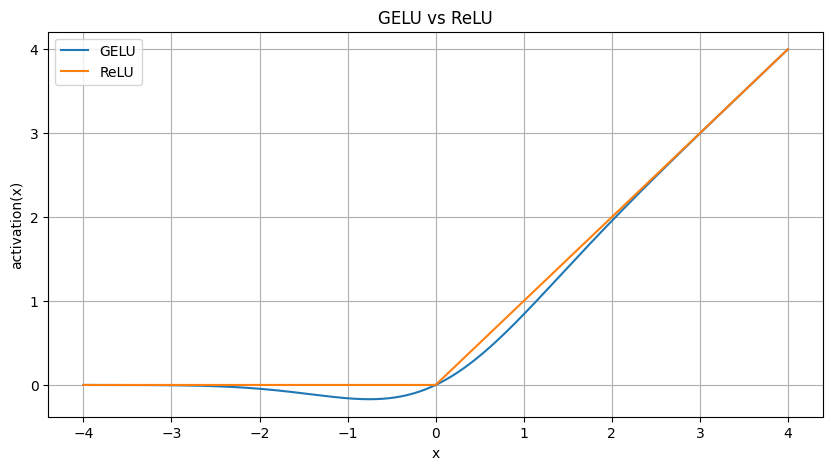

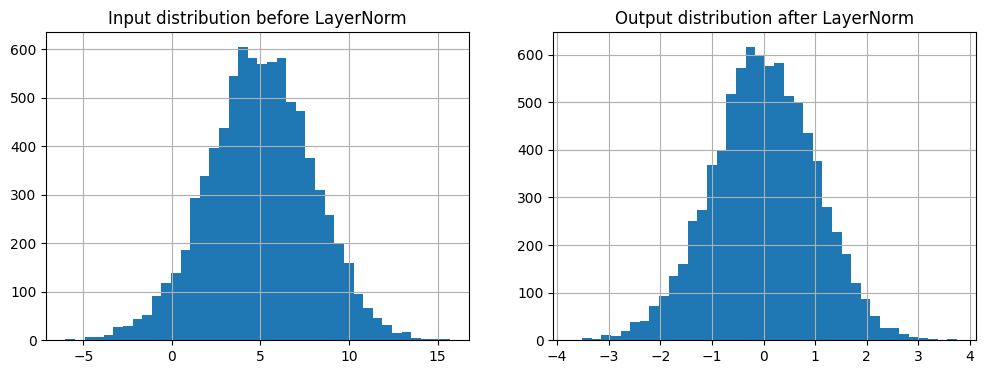

Mean before LN  : 5.000219345092773
Std before LN   : 2.9685754776000977
Mean after LN   : 4.9112713895738125e-09
Std after LN    : 0.9999994039535522


In [7]:

# Reference LayerNorm and GELU implementations + visuals.


def gelu_reference(x: np.ndarray) -> np.ndarray:
    """Fast tanh GELU approximation used in many practical kernels."""
    coeff = np.sqrt(2.0 / np.pi)
    return 0.5 * x * (1.0 + np.tanh(coeff * (x + 0.044715 * x ** 3)))



def layernorm_reference(x: np.ndarray, gamma: np.ndarray, beta: np.ndarray, eps: float = 1e-5) -> np.ndarray:
    """Reference LayerNorm over the last dimension."""
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    normalized = (x - mean) / np.sqrt(var + eps)
    return normalized * gamma + beta


# Plot the GELU curve for intuition.
xs = np.linspace(-4, 4, 400, dtype=np.float32)
gelus = gelu_reference(xs)
relus = np.maximum(xs, 0.0)

fig, ax = plt.subplots()
ax.plot(xs, gelus, label="GELU")
ax.plot(xs, relus, label="ReLU")
ax.set_title("GELU vs ReLU")
ax.set_xlabel("x")
ax.set_ylabel("activation(x)")
ax.legend()
plt.show()

# Show what LayerNorm does to one toy batch.
rows, hidden = 128, 64
x_ln = (3.0 * np.random.randn(rows, hidden) + 5.0).astype(np.float32)
gamma = np.ones(hidden, dtype=np.float32)
beta = np.zeros(hidden, dtype=np.float32)
y_ln = layernorm_reference(x_ln, gamma, beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_ln.ravel(), bins=40)
axes[0].set_title("Input distribution before LayerNorm")
axes[1].hist(y_ln.ravel(), bins=40)
axes[1].set_title("Output distribution after LayerNorm")
plt.show()

print("Mean before LN  :", float(x_ln.mean()))
print("Std before LN   :", float(x_ln.std()))
print("Mean after LN   :", float(y_ln.mean()))
print("Std after LN    :", float(y_ln.std()))


Tiny LayerNorm walkthrough
input row                : [ 2.  4.  4. 10.]
row mean                 : 5.0
row variance             : 9.0
normalized row           : [-0.999999 -0.333333 -0.333333  1.666666]


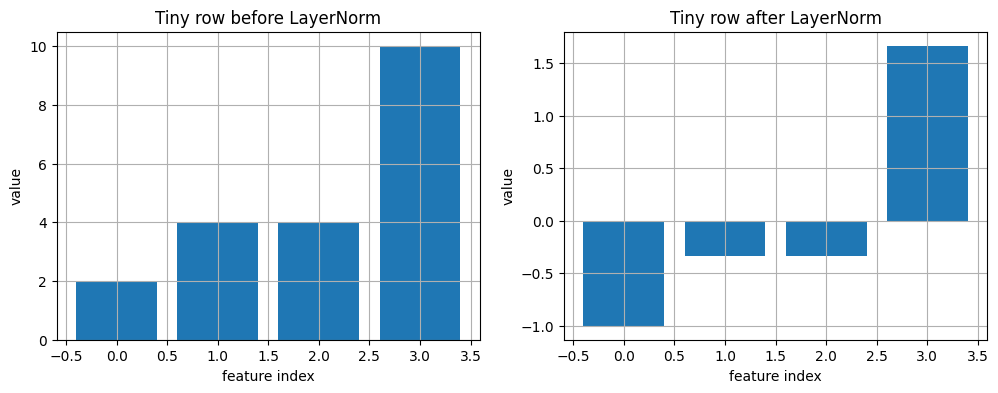

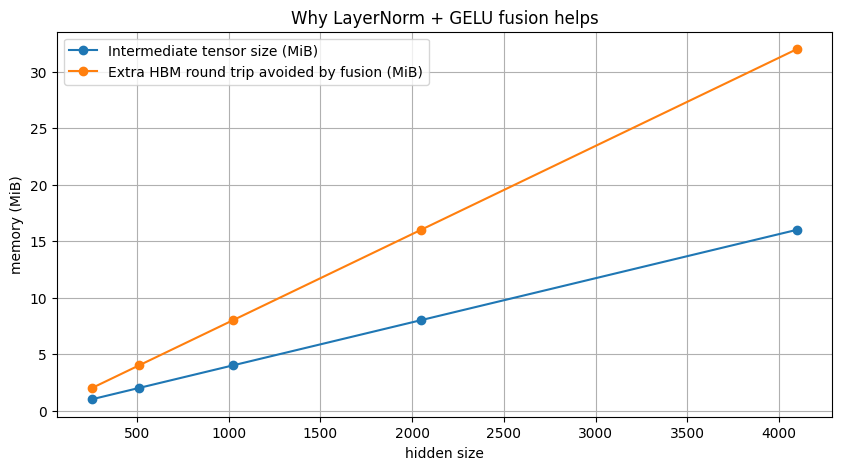

Interpretation:
- The arithmetic of GELU did not disappear.
- The main saving is often the avoided write/read of the intermediate tensor.
- That is why fusion is such a common optimization pattern in transformer kernels.


In [8]:
# Extra beginner example: walk through LayerNorm by hand on one tiny row,
# then build a simplified traffic model for separate vs fused LayerNorm+GELU.

tiny_row = np.array([[2.0, 4.0, 4.0, 10.0]], dtype=np.float32)
tiny_gamma = np.ones(4, dtype=np.float32)
tiny_beta = np.zeros(4, dtype=np.float32)

tiny_mean = tiny_row.mean(axis=-1, keepdims=True)
tiny_var = tiny_row.var(axis=-1, keepdims=True)
tiny_norm = layernorm_reference(tiny_row, tiny_gamma, tiny_beta)

print("Tiny LayerNorm walkthrough")
print("input row                :", tiny_row.ravel())
print("row mean                 :", tiny_mean.ravel()[0])
print("row variance             :", tiny_var.ravel()[0])
print("normalized row           :", np.round(tiny_norm.ravel(), 6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(tiny_row.shape[1]), tiny_row.ravel())
axes[0].set_title("Tiny row before LayerNorm")
axes[0].set_xlabel("feature index")
axes[0].set_ylabel("value")
axes[1].bar(np.arange(tiny_norm.shape[1]), tiny_norm.ravel())
axes[1].set_title("Tiny row after LayerNorm")
axes[1].set_xlabel("feature index")
axes[1].set_ylabel("value")
plt.show()

rows_demo = 2048
hidden_sizes = np.array([256, 512, 1024, 2048, 4096])
dtype_bytes = BYTES_PER_FP16
intermediate_bytes = rows_demo * hidden_sizes * dtype_bytes
extra_round_trip_bytes = 2 * intermediate_bytes

fig, ax = plt.subplots()
ax.plot(hidden_sizes, intermediate_bytes / (1024 ** 2), marker="o", label="Intermediate tensor size (MiB)")
ax.plot(hidden_sizes, extra_round_trip_bytes / (1024 ** 2), marker="o", label="Extra HBM round trip avoided by fusion (MiB)")
ax.set_title("Why LayerNorm + GELU fusion helps")
ax.set_xlabel("hidden size")
ax.set_ylabel("memory (MiB)")
ax.legend()
plt.show()

print("Interpretation:")
print("- The arithmetic of GELU did not disappear.")
print("- The main saving is often the avoided write/read of the intermediate tensor.")
print("- That is why fusion is such a common optimization pattern in transformer kernels.")



### CUDA kernel strategy for LayerNorm, GELU, and fused LayerNorm+GELU

For teaching purposes, the kernels below use a simple and readable design:
- **GELU kernel:** one thread per element.
- **LayerNorm kernel:** one block per row, block-wide reduction for mean and variance.
- **Fused kernel:** same reduction, but directly applies affine transform and GELU before writing out.

This is **not** the fastest possible implementation. Production kernels may use:
- warp shuffles,
- vectorized loads/stores,
- better occupancy tuning,
- specialized kernels for different hidden sizes,
- mixed precision with FP32 accumulation,
- compiler frameworks like Triton or custom CUDA C++ extensions.

Still, this notebook version captures the right algorithmic and memory-system ideas.


## What a fused reduction kernel is trying to achieve

A fused LayerNorm + GELU kernel has two jobs:

1. **Compute the normalization statistics correctly**
   - mean,
   - variance,
   - inverse standard deviation.

2. **Keep the normalized values hot**
   - in registers,
   - or in shared memory,
   - so the next operation can happen before the data goes back to HBM.

That is the whole strategic idea.

A beginner summary:

- **Separate kernels** are usually easier to write.
- **Fused kernels** are often harder to write but better for memory traffic.
- The reason is usually **data reuse**, not magical math.

This is why production engineers care so much about:
- reduction strategy,
- shared-memory usage,
- vectorized load/store patterns,
- and precision of accumulation.


In [9]:

# Custom CUDA kernels for GELU, LayerNorm, and fused LayerNorm+GELU.
# They are correctness-first kernels with extensive comments.

MAX_THREADS = 256


@cuda.jit(device=True)
def gelu_tanh_device(x):
    """Device function for the tanh-based GELU approximation."""
    coeff = math.sqrt(2.0 / math.pi)
    return 0.5 * x * (1.0 + math.tanh(coeff * (x + 0.044715 * x * x * x)))


@cuda.jit
def gelu_cuda_kernel(x, out):
    """
    Elementwise GELU kernel.
    Each thread handles one tensor element.
    """
    idx = cuda.grid(1)
    if idx < x.size:
        out.flat[idx] = gelu_tanh_device(float(x.flat[idx]))


@cuda.jit
def layernorm_cuda_kernel(x, gamma, beta, eps, out):
    """
    LayerNorm kernel over the last dimension.

    Design:
    - One CUDA block handles one row.
    - Threads cooperate to compute row mean and variance.
    - Partial sums live in shared memory.
    """
    row = cuda.blockIdx.x
    tid = cuda.threadIdx.x
    hidden = x.shape[1]

    partial_sum = cuda.shared.array(shape=MAX_THREADS, dtype=float32)
    partial_sq_sum = cuda.shared.array(shape=MAX_THREADS, dtype=float32)
    mean_shared = cuda.shared.array(shape=1, dtype=float32)
    inv_std_shared = cuda.shared.array(shape=1, dtype=float32)

    # Stride through the row so the kernel works even if hidden > blockDim.x.
    s = 0.0
    sq = 0.0
    for col in range(tid, hidden, cuda.blockDim.x):
        val = float(x[row, col])
        s += val
        sq += val * val

    partial_sum[tid] = s
    partial_sq_sum[tid] = sq
    cuda.syncthreads()

    # Tree reduction to combine thread-local partial sums.
    stride = cuda.blockDim.x // 2
    while stride > 0:
        if tid < stride:
            partial_sum[tid] += partial_sum[tid + stride]
            partial_sq_sum[tid] += partial_sq_sum[tid + stride]
        cuda.syncthreads()
        stride //= 2

    if tid == 0:
        mean = partial_sum[0] / hidden
        var = partial_sq_sum[0] / hidden - mean * mean
        if var < 0.0:
            var = 0.0  # Numerical safety for tiny negative values from finite precision.
        mean_shared[0] = mean
        inv_std_shared[0] = 1.0 / math.sqrt(var + eps)
    cuda.syncthreads()

    mean = mean_shared[0]
    inv_std = inv_std_shared[0]

    # Normalize and apply the learnable affine transform.
    for col in range(tid, hidden, cuda.blockDim.x):
        normalized = (float(x[row, col]) - mean) * inv_std
        out[row, col] = normalized * float(gamma[col]) + float(beta[col])


@cuda.jit
def fused_layernorm_gelu_kernel(x, gamma, beta, eps, out):
    """
    Fused LayerNorm + GELU kernel.

    Compared with running LayerNorm and GELU separately, this kernel avoids writing the
    LayerNorm output to global memory and reading it back for GELU.
    """
    row = cuda.blockIdx.x
    tid = cuda.threadIdx.x
    hidden = x.shape[1]

    partial_sum = cuda.shared.array(shape=MAX_THREADS, dtype=float32)
    partial_sq_sum = cuda.shared.array(shape=MAX_THREADS, dtype=float32)
    mean_shared = cuda.shared.array(shape=1, dtype=float32)
    inv_std_shared = cuda.shared.array(shape=1, dtype=float32)

    s = 0.0
    sq = 0.0
    for col in range(tid, hidden, cuda.blockDim.x):
        val = float(x[row, col])
        s += val
        sq += val * val

    partial_sum[tid] = s
    partial_sq_sum[tid] = sq
    cuda.syncthreads()

    stride = cuda.blockDim.x // 2
    while stride > 0:
        if tid < stride:
            partial_sum[tid] += partial_sum[tid + stride]
            partial_sq_sum[tid] += partial_sq_sum[tid + stride]
        cuda.syncthreads()
        stride //= 2

    if tid == 0:
        mean = partial_sum[0] / hidden
        var = partial_sq_sum[0] / hidden - mean * mean
        if var < 0.0:
            var = 0.0
        mean_shared[0] = mean
        inv_std_shared[0] = 1.0 / math.sqrt(var + eps)
    cuda.syncthreads()

    mean = mean_shared[0]
    inv_std = inv_std_shared[0]

    for col in range(tid, hidden, cuda.blockDim.x):
        normalized = (float(x[row, col]) - mean) * inv_std
        affine = normalized * float(gamma[col]) + float(beta[col])
        out[row, col] = gelu_tanh_device(affine)


# Validate all kernels against NumPy reference implementations.
rows = 16
hidden = 128
x = np.random.randn(rows, hidden).astype(np.float32)
gamma = np.random.randn(hidden).astype(np.float32)
beta = np.random.randn(hidden).astype(np.float32)

x_d = cuda.to_device(x)
gamma_d = cuda.to_device(gamma)
beta_d = cuda.to_device(beta)

layernorm_out_d = cuda.device_array_like(x_d)
gelu_out_d = cuda.device_array_like(x_d)
fused_out_d = cuda.device_array_like(x_d)

threads = 128
blocks = rows

layernorm_cuda_kernel[blocks, threads](x_d, gamma_d, beta_d, 1e-5, layernorm_out_d)
gel_blocks = (x.size + 255) // 256
gelu_cuda_kernel[gel_blocks, 256](layernorm_out_d, gelu_out_d)
fused_layernorm_gelu_kernel[blocks, threads](x_d, gamma_d, beta_d, 1e-5, fused_out_d)

layernorm_then_gelu = gelu_out_d.copy_to_host()
fused_out = fused_out_d.copy_to_host()
reference = gelu_reference(layernorm_reference(x, gamma, beta))

separate_error = np.max(np.abs(layernorm_then_gelu - reference))
fused_error = np.max(np.abs(fused_out - reference))
fused_vs_separate_error = np.max(np.abs(fused_out - layernorm_then_gelu))

print("Separate LayerNorm -> GELU max abs error:", float(separate_error))
print("Fused LayerNorm + GELU max abs error   :", float(fused_error))
print("Fused vs separate max abs error        :", float(fused_vs_separate_error))

assert separate_error < 1e-5
assert fused_error < 1e-5
assert fused_vs_separate_error < 1e-5


Separate LayerNorm -> GELU max abs error: 5.071092950004186e-07
Fused LayerNorm + GELU max abs error   : 5.071092950004186e-07
Fused vs separate max abs error        : 4.76837158203125e-07


In [10]:
# Optional real-GPU benchmark: separate LayerNorm->GELU versus fused LayerNorm+GELU.
# This benchmark uses the educational Numba kernels defined above.

if not HAS_TORCH_CUDA or USING_CUDA_SIMULATOR:
    print("Skipping real-GPU fused-kernel benchmark because no real CUDA device is active in this runtime.")
else:
    rows_bench = 1024
    hidden_bench = 256
    threads = 128
    iters = 20

    x_bench = np.random.randn(rows_bench, hidden_bench).astype(np.float32)
    gamma_bench = np.random.randn(hidden_bench).astype(np.float32)
    beta_bench = np.random.randn(hidden_bench).astype(np.float32)

    x_bench_d = cuda.to_device(x_bench)
    gamma_bench_d = cuda.to_device(gamma_bench)
    beta_bench_d = cuda.to_device(beta_bench)
    ln_tmp_d = cuda.device_array_like(x_bench_d)
    gelu_tmp_d = cuda.device_array_like(x_bench_d)
    fused_tmp_d = cuda.device_array_like(x_bench_d)

    blocks = rows_bench
    gel_blocks = (x_bench.size + 255) // 256

    for _ in range(3):
        layernorm_cuda_kernel[blocks, threads](x_bench_d, gamma_bench_d, beta_bench_d, 1e-5, ln_tmp_d)
        gelu_cuda_kernel[gel_blocks, 256](ln_tmp_d, gelu_tmp_d)
        fused_layernorm_gelu_kernel[blocks, threads](x_bench_d, gamma_bench_d, beta_bench_d, 1e-5, fused_tmp_d)
    cuda.synchronize()

    start = time.perf_counter()
    for _ in range(iters):
        layernorm_cuda_kernel[blocks, threads](x_bench_d, gamma_bench_d, beta_bench_d, 1e-5, ln_tmp_d)
        gelu_cuda_kernel[gel_blocks, 256](ln_tmp_d, gelu_tmp_d)
    cuda.synchronize()
    separate_ms = 1000.0 * (time.perf_counter() - start) / iters

    start = time.perf_counter()
    for _ in range(iters):
        fused_layernorm_gelu_kernel[blocks, threads](x_bench_d, gamma_bench_d, beta_bench_d, 1e-5, fused_tmp_d)
    cuda.synchronize()
    fused_ms = 1000.0 * (time.perf_counter() - start) / iters

    separate_host = gelu_tmp_d.copy_to_host()
    fused_host = fused_tmp_d.copy_to_host()
    max_diff = np.max(np.abs(separate_host - fused_host))

    print(f"Separate LayerNorm->GELU average time: {separate_ms:.3f} ms")
    print(f"Fused LayerNorm+GELU average time    : {fused_ms:.3f} ms")
    print(f"Separate / fused speed ratio         : {separate_ms / fused_ms:.3f}x")
    print(f"Max abs difference                   : {max_diff:.6e}")
    print("\nInterpretation:")
    print("- Speedups vary by shape, block size, and implementation quality.")
    print("- Even when the arithmetic is similar, fusion can help because it reduces memory traffic and kernel-launch overhead.")


Skipping real-GPU fused-kernel benchmark because no real CUDA device is active in this runtime.


## Training memory versus inference memory: do not mix them up

A lot of beginners accidentally blur training and inference into one bucket.  
That causes confusion.

### During training
The big memory consumers usually include:

- model weights,
- optimizer state,
- gradients,
- and **saved activations** for backward.

This is where ideas like **activation checkpointing** matter a lot.

### During autoregressive inference
The big memory consumers usually include:

- model weights,
- **KV cache** that grows with generated sequence length,
- batching overhead,
- and serving-system memory fragmentation.

This is where ideas like:

- **GQA / MQA**,
- **paged KV cache**,
- **continuous batching**,
- and efficient attention backends

become central.

A concise interview answer is:

> "Training memory is often dominated by activations and optimizer state, while inference memory is often dominated by weights and the growing KV cache."



## 4. Memory-efficient attention patterns

This section connects kernel-level ideas to full-model behavior.

### 4.1 Full attention materialization is quadratic
If you materialize the score matrix for attention, its shape is `[B, H, N, N]`, so memory grows as

$$
O(BHN^2).
$$

That becomes painful quickly as sequence length grows.

### 4.2 FlashAttention / PyTorch SDPA idea
FlashAttention is exact attention, but it is **IO-aware**: instead of forming the whole score matrix in HBM, it streams tiles through on-chip memory and performs online normalization. PyTorch's `scaled_dot_product_attention` can dispatch to optimized backends such as flash attention or other efficient implementations when the hardware, shapes, and dtypes allow it.

### 4.3 MQA and GQA reduce KV cache size
For autoregressive inference, KV cache memory is

$$
2 \times L \times B \times T \times H_{kv} \times D_{head} \times \text{bytes}.
$$

The crucial knob is $H_{kv}$, the number of **key/value heads**:
- **MHA:** $H_{kv} = H$
- **GQA:** $H_{kv} < H$
- **MQA:** $H_{kv} = 1$

This is why MQA/GQA are so important in serving systems.

### 4.4 Other memory-saving patterns
- **Sliding-window / local attention:** store only a band, not the full matrix.
- **Activation checkpointing:** save fewer tensors and recompute some work in backward.
- **Paged KV caches:** reduce fragmentation and make serving more efficient.


In [11]:

# Small SDPA demo.
# On CPU this will use a math backend. On CUDA, PyTorch may pick a faster backend depending on
# shapes, dtypes, and hardware support.

q = torch.randn(2, 4, 16, 32, dtype=torch.float32)
k = torch.randn(2, 4, 16, 32, dtype=torch.float32)
v = torch.randn(2, 4, 16, 32, dtype=torch.float32)

sdpa_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
print("SDPA output shape:", tuple(sdpa_out.shape))


SDPA output shape:

(2, 4, 16, 32)


In [12]:
# Optional real-GPU SDPA benchmark.
# This cell is designed for your local RTX 5060 or Colab GPU.

if not HAS_TORCH_CUDA:
    print("Skipping GPU SDPA benchmark because torch.cuda.is_available() is False in this runtime.")
else:
    device = "cuda"
    dtype = torch.float16
    benchmark_seq_lengths = [256, 512, 1024]
    batch_size = 1
    num_heads = 8
    head_dim = 64
    iters = 30

    results = []
    for n in benchmark_seq_lengths:
        q = torch.randn(batch_size, num_heads, n, head_dim, device=device, dtype=dtype)
        k = torch.randn(batch_size, num_heads, n, head_dim, device=device, dtype=dtype)
        v = torch.randn(batch_size, num_heads, n, head_dim, device=device, dtype=dtype)
        for _ in range(5):
            _ = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(iters):
            _ = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        torch.cuda.synchronize()
        avg_ms = 1000.0 * (time.perf_counter() - start) / iters
        score_mib = bytes_to_mib(estimate_attention_score_bytes(batch_size, num_heads, n, BYTES_PER_FP16))
        results.append((n, avg_ms, score_mib))

    print("GPU SDPA benchmark results")
    for n, avg_ms, score_mib in results:
        print(f"seq_len={n:4d}  avg_time={avg_ms:8.3f} ms  full_score_tensor={score_mib:8.2f} MiB")

    fig, ax1 = plt.subplots()
    ax1.plot([r[0] for r in results], [r[1] for r in results], marker="o")
    ax1.set_title("PyTorch SDPA runtime vs sequence length on GPU")
    ax1.set_xlabel("sequence length")
    ax1.set_ylabel("average runtime (ms)")
    plt.show()

    print("Interpretation:")
    print("- Runtime generally rises with sequence length.")
    print("- The larger point is that optimized attention backends avoid unnecessary materialization and reduce IO pressure.")
    print("- Exact backend selection can depend on hardware, dtype, shape, and PyTorch version.")


Skipping GPU SDPA benchmark because torch.cuda.is_available() is False in this runtime.


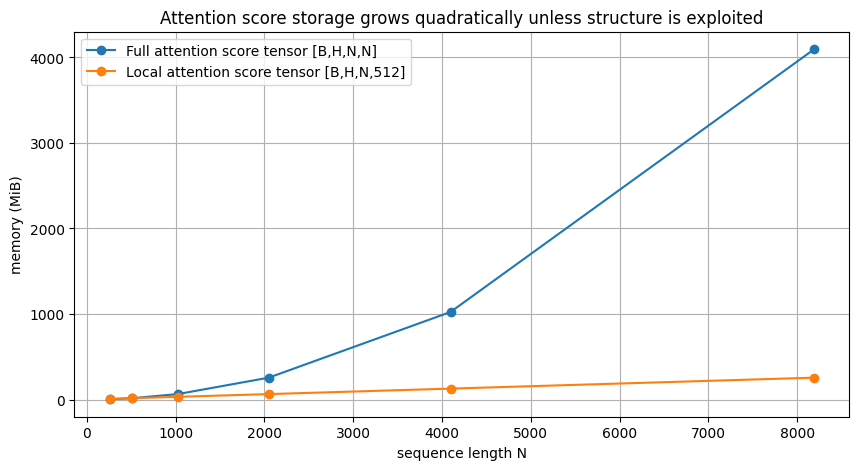

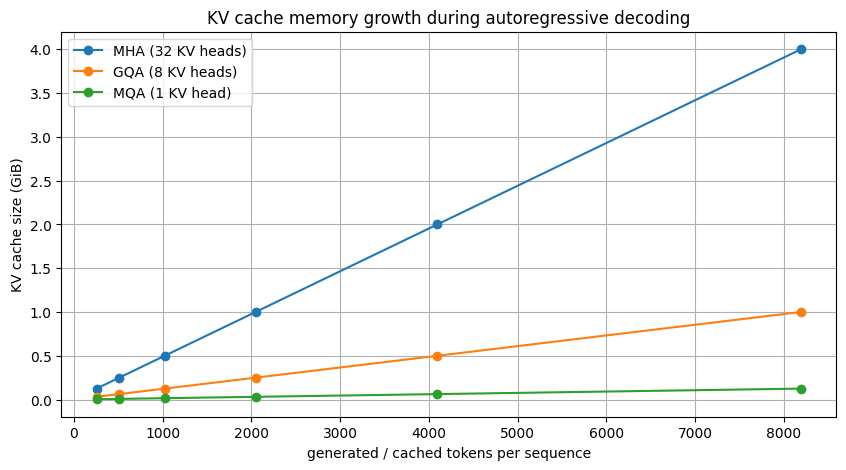

Sequence length 2048 -> MHA: 1.00 GiB, GQA-8: 0.25 GiB, MQA: 0.03 GiB
Sequence length 8192 -> MHA: 4.00 GiB, GQA-8: 1.00 GiB, MQA: 0.12 GiB


In [13]:

# Memory scaling plots for attention score tensors and KV caches.

seq_lengths = np.array([256, 512, 1024, 2048, 4096, 8192])

# Example 1: materialized attention score memory for one illustrative setup.
batch_size = 1
num_heads = 32
dtype_bytes = BYTES_PER_BF16
full_attention_mib = [bytes_to_mib(estimate_attention_score_bytes(batch_size, num_heads, n, dtype_bytes)) for n in seq_lengths]
local_window = 512
local_attention_mib = [bytes_to_mib(estimate_local_attention_score_bytes(batch_size, num_heads, n, local_window, dtype_bytes)) for n in seq_lengths]

fig, ax = plt.subplots()
ax.plot(seq_lengths, full_attention_mib, marker='o', label='Full attention score tensor [B,H,N,N]')
ax.plot(seq_lengths, local_attention_mib, marker='o', label=f'Local attention score tensor [B,H,N,{local_window}]')
ax.set_title('Attention score storage grows quadratically unless structure is exploited')
ax.set_xlabel('sequence length N')
ax.set_ylabel('memory (MiB)')
ax.legend()
plt.show()

# Example 2: KV cache memory growth for MHA vs GQA vs MQA.
# These are illustrative model settings similar to many LLM decoder stacks.
num_layers = 32
batch_size = 1
head_dim = 128
num_heads = 32
mha_gib = [bytes_to_gib(estimate_kv_cache_bytes(num_layers, batch_size, n, num_heads, head_dim, BYTES_PER_BF16)) for n in seq_lengths]
gqa_gib = [bytes_to_gib(estimate_kv_cache_bytes(num_layers, batch_size, n, 8, head_dim, BYTES_PER_BF16)) for n in seq_lengths]
mqa_gib = [bytes_to_gib(estimate_kv_cache_bytes(num_layers, batch_size, n, 1, head_dim, BYTES_PER_BF16)) for n in seq_lengths]

fig, ax = plt.subplots()
ax.plot(seq_lengths, mha_gib, marker='o', label='MHA (32 KV heads)')
ax.plot(seq_lengths, gqa_gib, marker='o', label='GQA (8 KV heads)')
ax.plot(seq_lengths, mqa_gib, marker='o', label='MQA (1 KV head)')
ax.set_title('KV cache memory growth during autoregressive decoding')
ax.set_xlabel('generated / cached tokens per sequence')
ax.set_ylabel('KV cache size (GiB)')
ax.legend()
plt.show()

# Print a few concrete numbers because interviewers often ask for quick mental math.
for n in [2048, 8192]:
    mha = bytes_to_gib(estimate_kv_cache_bytes(num_layers, batch_size, n, num_heads, head_dim, BYTES_PER_BF16))
    gqa = bytes_to_gib(estimate_kv_cache_bytes(num_layers, batch_size, n, 8, head_dim, BYTES_PER_BF16))
    mqa = bytes_to_gib(estimate_kv_cache_bytes(num_layers, batch_size, n, 1, head_dim, BYTES_PER_BF16))
    print(f"Sequence length {n:>4d} -> MHA: {mha:.2f} GiB, GQA-8: {gqa:.2f} GiB, MQA: {mqa:.2f} GiB")


KV-cache what-if report for a single 8K-context request
MHA: kv_heads=32  cache=4.000 GiB
GQA: kv_heads= 8  cache=1.000 GiB
MQA: kv_heads= 1  cache=0.125 GiB


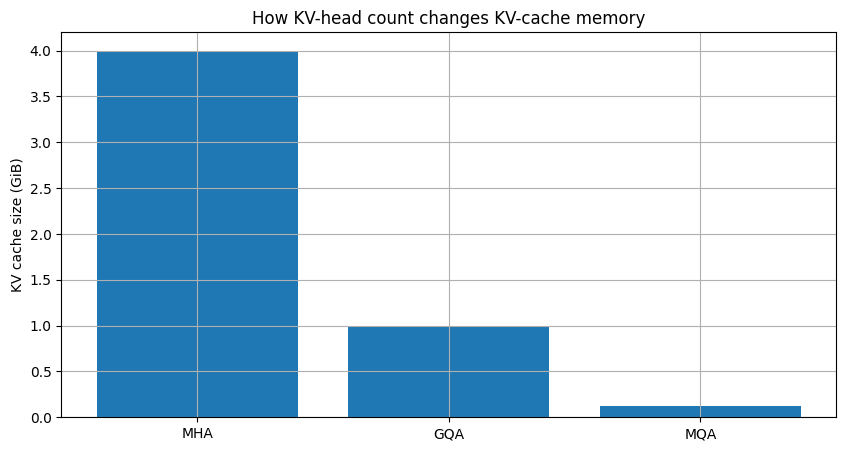

Interview lesson:
- Query heads affect attention compute, but KV heads dominate KV-cache memory.
- That is why GQA and MQA are especially important for serving and long-context inference.


In [14]:
# Extra beginner tool: a what-if KV cache calculator for interview practice.
# The goal is to make the KV-cache formula feel concrete.

def kv_cache_report(
    num_layers: int,
    batch_size: int,
    seq_len: int,
    num_query_heads: int,
    num_kv_heads: int,
    head_dim: int,
    dtype_bytes: int = BYTES_PER_BF16,
):
    """Return a dictionary with KV-cache size estimates."""
    total_bytes = estimate_kv_cache_bytes(
        num_layers=num_layers,
        batch_size=batch_size,
        seq_len=seq_len,
        num_kv_heads=num_kv_heads,
        head_dim=head_dim,
        dtype_bytes=dtype_bytes,
    )
    return {
        "layers": num_layers,
        "batch_size": batch_size,
        "seq_len": seq_len,
        "query_heads": num_query_heads,
        "kv_heads": num_kv_heads,
        "head_dim": head_dim,
        "gib": bytes_to_gib(total_bytes),
    }

example_cfg = dict(num_layers=32, batch_size=1, seq_len=8192, num_query_heads=32, head_dim=128)
reports = [
    kv_cache_report(**example_cfg, num_kv_heads=32),
    kv_cache_report(**example_cfg, num_kv_heads=8),
    kv_cache_report(**example_cfg, num_kv_heads=1),
]

print("KV-cache what-if report for a single 8K-context request")
for r, label in zip(reports, ["MHA", "GQA", "MQA"]):
    print(f"{label:>3s}: kv_heads={r['kv_heads']:2d}  cache={r['gib']:.3f} GiB")

fig, ax = plt.subplots()
labels = ["MHA", "GQA", "MQA"]
sizes = [r["gib"] for r in reports]
ax.bar(labels, sizes)
ax.set_title("How KV-head count changes KV-cache memory")
ax.set_ylabel("KV cache size (GiB)")
plt.show()

print("Interview lesson:")
print("- Query heads affect attention compute, but KV heads dominate KV-cache memory.")
print("- That is why GQA and MQA are especially important for serving and long-context inference.")


In [15]:

# Activation checkpointing pattern.
# This example is intentionally small and CPU-safe. The point is to show the API shape and the idea.

from torch.utils.checkpoint import checkpoint

class TinyMLP(torch.nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.lin1 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = torch.nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        return self.lin2(F.gelu(self.lin1(x)))


tiny_block = TinyMLP(hidden_dim=32)
x = torch.randn(8, 32, requires_grad=True)

# Direct forward.
out_direct = tiny_block(x)

# Checkpointed forward. This trades extra recomputation for lower saved activation memory.
out_ckpt = checkpoint(tiny_block, x, use_reentrant=False)

# They should match numerically.
max_diff = (out_direct - out_ckpt).abs().max().item()
print("Checkpointed vs direct max diff:", max_diff)
assert max_diff < 1e-6


Checkpointed vs direct max diff: 0.0


## Correctness-first debugging checklist for custom kernels

Before trying to optimize a kernel, do these in order:

1. **Write a small reference implementation**
   - NumPy or PyTorch on CPU is fine.

2. **Test tiny shapes first**
   - tiny tensors make indexing mistakes easier to diagnose.

3. **Compare numerically**
   - max absolute error,
   - maybe max relative error,
   - and shape / dtype checks.

4. **Use deterministic seeds**
   - so failures are reproducible.

5. **Warm up before timing**
   - do not confuse compilation or lazy initialization with runtime.

6. **Benchmark only after correctness**
   - a wrong fast kernel is useless.

This notebook follows that pattern repeatedly, which is exactly the right professional habit.



## 5. How this maps to your HP desktop and Colab

### Your local desktop
For your **HP OmniDesk (Intel Core Ultra 7, 32 GB RAM, RTX 5060, 1 TB SSD)**:
- This notebook is very realistic for **learning and interview prep**.
- You can run the small correctness tests locally.
- You should keep tensor sizes moderate and focus on **kernel correctness, profiling habits, and memory math**.
- For large-scale benchmarking, use **Google Colab** or another machine with a larger datacenter GPU.

### What to focus on in interviews
A strong answer usually covers all four levels:
1. **Math / algorithm:** what is being computed?
2. **Kernel mapping:** how do threads/warps/blocks cooperate?
3. **Memory system:** what is read from / written to HBM, shared memory, registers?
4. **System consequence:** how does this change training throughput, inference latency, or batch size?

### Common interview questions you should be ready for
- Why is RoPE usually more bandwidth-sensitive than compute-sensitive?
- Why does fusing LayerNorm and GELU help even if arithmetic does not change much?
- Why does attention become harder at long sequence length?
- Why do GQA and MQA help inference more than training?
- What is the difference between reducing FLOPs and reducing **HBM traffic**?
- Why can FlashAttention be faster without approximating attention?
- How would you validate a new kernel for correctness before benchmarking it?



## 6. Quick interview crib sheet

### RoPE in one sentence
"RoPE multiplies each 2D channel pair by a position-dependent rotation, which preserves pair norms and encodes relative position structure directly in the attention inner product."

### Why fusion helps in one sentence
"Fusion reduces kernel launches and avoids writing an intermediate tensor to HBM and then reading it back, so it often improves throughput even when FLOPs are unchanged."

### Why attention is hard in one sentence
"Naive attention is expensive because materialized score/probability tensors scale as $O(N^2)$ in sequence length, and moving those tensors dominates runtime and memory."

### Why GQA/MQA matter in one sentence
"They reduce the number of KV heads, which directly shrinks KV cache size and memory bandwidth during decoding."

### What makes a good CUDA kernel answer
Mention at least these words:
- **coalesced loads/stores**
- **shared memory or registers**
- **occupancy**
- **reduction strategy**
- **FP32 accumulation**
- **correctness validation**
- **benchmarking without compile overhead**


## Common beginner mistakes on these topics

### Mistake 1: thinking fewer FLOPs always means faster
Not necessarily.  
On modern GPUs, many transformer sub-ops are limited more by **memory traffic** than by arithmetic throughput.

### Mistake 2: treating all attention optimization as approximation
FlashAttention is a good counterexample: it is **exact attention**, but implemented in an IO-aware way.

### Mistake 3: forgetting the difference between compute optimization and memory optimization
A kernel can do the same math but still be faster because it:
- launches fewer kernels,
- avoids intermediate writes,
- or reuses on-chip memory better.

### Mistake 4: benchmarking the first iteration only
The first iteration may include:
- compilation,
- cache setup,
- autotuning,
- lazy initialization.

### Mistake 5: skipping precision thinking
For reductions like LayerNorm, accumulating in **FP32** is often part of getting stable results.

### Mistake 6: discussing training and inference as if they have the same bottlenecks
They overlap, but the dominant memory bottlenecks are often different.



## 7. Exercises for deeper mastery

1. **RoPE kernel extension:** support input shape `[batch, seq, heads, dim]` directly instead of flattening tokens.
2. **Backward pass practice:** derive gradients for GELU and think about what a backward kernel would need.
3. **LayerNorm variants:** implement RMSNorm and compare the reduction pattern.
4. **KV cache math:** change the plot to match a specific open model architecture you care about.
5. **Profiling step:** on a real GPU, benchmark separate LayerNorm + GELU vs a fused implementation.
6. **FlashAttention connection:** explain how online softmax avoids materializing the full score matrix.


## Local environment note

A separate detailed setup file is generated alongside this notebook for:

- **Windows host + WSL2 Ubuntu**
- **HP OmniDesk + RTX 5060**
- **VS Code Remote WSL**
- **JupyterLab**
- **PyTorch + Numba CUDA workflow**

That guide is intended to be followed step by step by a beginner.

Inside this notebook, the rule is simple:

- **CPU-only environment:** correctness sections still run.
- **Real CUDA environment:** the optional benchmark sections also run.
- **No silent failure:** GPU-only cells explicitly say when they are skipped.



## 8. References

Primary / official sources behind the notebook:

1. Vaswani et al. (2017), **Attention Is All You Need**.
2. Su et al. (2021), **RoFormer: Enhanced Transformer with Rotary Position Embedding**.
3. Ba, Kiros, Hinton (2016), **Layer Normalization**.
4. Hendrycks, Gimpel (2016), **Gaussian Error Linear Units (GELUs)**.
5. Dao et al. (2022), **FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness**.
6. Dao (2023), **FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning**.
7. Shazeer (2019), **Fast Transformer Decoding: One Write-Head is All You Need**.
8. Ainslie et al. (2023), **GQA: Training Generalized Multi-Query Transformer Models**.
9. Kwon et al. (2023), **Efficient Memory Management for Large Language Model Serving with PagedAttention**.
10. Official PyTorch docs for **scaled_dot_product_attention** and **torch.utils.checkpoint**.
11. Official NVIDIA **CUDA C++ Programming Guide** and **CUDA C++ Best Practices Guide**.

A good follow-up after this notebook is to rewrite the educational kernels in either:
- **Triton** for fast iteration, or
- **C++/CUDA extensions** for closer-to-production control.


## 9. End-to-End System Picture: Where Each Component Lives

You've learned individual kernels (RoPE, LayerNorm+GELU, Attention). Now: **where do they appear in a real LLM serving system, and what dominates?**

### Real Model Profile: 70B Parameter Model

Typical architecture:
- **Embedding layer:** token → 4096-dim vector
- **80 transformer blocks**, each with:
  - **LayerNorm** (pre-attention) → **RoPE** (in-attention) → **Attention** → **Dropout**
  - **LayerNorm** (pre-FFN) → **GELU** → **Linear** (4×) → **Linear** (1×) → **Dropout**
- **Final LayerNorm** → **Linear projection** (to vocab)

### Prefill Phase (e.g., 2048 input tokens, 8 GPUs, batch size 1)

```
Prefill (processing 2048 tokens in parallel):
├─ Embedding lookup: < 1% time (vectorized, cache-friendly)
├─ Per block (80 iterations):
│  ├─ LayerNorm: ~2-3% (O(T × H), low computation/memory ratio, but many blocks)
│  ├─ RoPE: ~1-2% (computation inside attention, fused in optimized code)
│  ├─ Attention:
│  │  ├─ Q @ K^T : ~5% (compute-bound, 2048² = 4M operations across batch)
│  │  ├─ Softmax: < 1% (fused with attention in FlashAttention)
│  │  └─ Score @ V: ~5% (another matmul)
│  ├─ Attention total: ~10-12% per block × 80 = major component
│  ├─ FFN (Linear-GELU-Linear): ~40-50% per block
│  │  └─ 70B model: (70B × 4 / 8 GPUs) = 35B params per GPU
│  │  └─ Prefill: compute-bound, FMA-heavy
│  └─ Dropout + residuals: negligible
│
└─ Final projection: ~1% (output logits for all 2048 positions)

**Prefill bottleneck: MLP (FFN) is typically compute-bound.**
- Time: ~2-5 seconds for 2048 tokens on 8× H100
- Key lever: batch more requests (if you have them)
- Kernel optimization impact: 1.3-1.5× speedup if you fuse LayerNorm+GELU
- System optimization impact: 2-3× speedup if you overlap compute with I/O
```

### Decode Phase (generating 1 token at a time, 100 requests in-flight)

```
Decode (generating 1 new token per request, 100 in-flight):
├─ Embedding lookup: < 1% (1 token at a time is cache-friendly)
├─ Per block (80 iterations):
│  ├─ LayerNorm: ~1% (O(H) per token, very lightweight)
│  ├─ RoPE: ~1% (compute is minimal for 1 token)
│  ├─ Attention:
│  │  ├─ Q projection: ~2% (shape [100, 1, 8, 64])
│  │  ├─ Compute Q @ cached_keys: ~2% ([100, 1, 8] @ [100, 2048, 8] = 1.6M simple ops)
│  │  │  └─ **BOTTLENECK: Reading 20GB KV cache from HBM**
│  │  ├─ Softmax: < 1% (very fast, 2048 elements)
│  │  └─ Score @ cached_values: ~2% (read 20GB again)
│  ├─ Attention total: ~6% per block × 80 = ~480% if sequential
│  │  └─ But KV cache hits L2, so batched: ~10-15% total
│  ├─ FFN: ~40-50% per block
│  │  └─ Decode: memory-bound (weights >> activations)
│  │  └─ Key insight: FFN activations are O(B × T × H), same as prefill, but KV fetches are new
│  └─ Outputs queued in KV cache
│
└─ Final projection: < 1% (1 logit probability per request)

**Decode bottleneck: depends on batch size.**
- Batch size 1: KV cache memory bandwidth (compute-bound only by overlapping)
- Batch size 100: balanced, but MLP still dominates compute
- Batch size 1000: still memory-bound (hitting HBM random access limits)
- Time per token: ~50-100ms per token across 100 requests = 0.5-1ms per request
```

### Key System Insight: Prefill vs Decode Trade-off

| Metric | Prefill (2048 tok) | Decode (1 tok) |
|--------|-------------------|-----------------|
| Compute per token | High (amortized) | Low (direct) |
| Memory bandwidth utilization | Good | Excellent but bottlenecked on KV |
| FLOPs / memory access ratio | ~1-2 (relatively balanced) | ~0.1 (very memory-bound) |
| What moved the needle | Batch more requests | Continuous batching + KV optimization |
| Kernel optimization ROI | 1.3× | 1.05× (diminishing returns) |
| System optimization ROI | 2-3× (overlapping, fusion) | 3-8× (batching, scheduling) |

**For infrastructure engineers:** You can see why:
- **Prefill bottleneck is algorithmic** (can't reduce FFN FLOPs much). Kernel fusion helps. Overlapping with communication helps more.
- **Decode bottleneck is memory layout** (KV cache fetches). GQA/MQA reduce KV size by 8-16×. Paged KV cache reduces fragmentation. Continuous batching hides memory latency.
- **Production systems typically prefer high-batch prefill + continuous-batch decode** over kernel optimization.


---

## 10. Real Bottleneck Analysis: Profiling Methodology and Decision Tree

You've seen the components. Now: **How do you actually find the bottleneck in your system?**

### Profiling Tools and What They Tell You

#### Tool 1: `nvidia-smi` (System-Level Overview)

```bash
watch -n 0.1 nvidia-smi
```

Look for:
- **GPU Util:** If < 80% during model inference → CPU is slow, I/O is slow, or kernel is launching too slowly.
- **Memory Used:** If stable but below average → kernel is thrashing cache. If growing → memory leak or gradual batch accumulation.
- **Power:** If maxed out (350W on H100) → you're hitting thermal limit, GPU is compute-bound.

#### Tool 2: `torch.profiler` (Per-Operation Breakdown)

```python
import torch

# For a single prefill forward pass:
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    record_shapes=True,
    profile_memory=True,
) as prof:
    logits = model.forward(input_ids, attention_mask=None)  # prefill

# Print top 20 operations by duration
prof.key_averages().table(sort_by="cuda_time_total", row_limit=20)

# Look for:
# - Linear ops taking 45-50% of time? FFN is bottleneck.
# - Attention (mm + softmax) taking only 10-15%? Decode phase.
# - LayerNorm < 3%? Fusion would help but not game-changing.
```

Expected output structure:
```
                                                  Self CPU   Self CUDA   # Calls
aten::mm                                          10.5ms     2500.0ms       480      ← FFN linear layers
aten::_scaled_dot_product_attention_impl           3.2ms      520.0ms       160      ← Attention (batched)
aten::native_layer_norm                           2.1ms      180.0ms       240      ← LayerNorm (pre-attn + pre-FFN)
aten::gelu_backward                                0.8ms       95.0ms       160      ← GELU doesn't dominate
aten::gelu                                         0.5ms       65.0ms       160
aten::sigmoid_backward                             0.3ms       12.0ms       160
aten::sum                                          0.1ms        8.0ms       320
```

**Interpretation:**
- FFN (`aten::mm`) is **40-50% of execution time** in prefill.
- Attention (including RoPE applied inside) is **15-20% of execution time**.
- LayerNorm is **5-8%** (fusion would save ~15% overall).

#### Tool 3: `NVIDIA NSys` (Kernel-Level Timeline)

```bash
nsys profile -o my_profile.nsys-rep python inference_script.py
# Open in NVIDIA Nsight Systems GUI
```

Visualize:
- **Kernel occupancy:** Are kernels fully using the GPU (>90% SM utilization)?
- **Memory throughput:** Peak BW achieved vs theoretical (1456 GB/s for H100).
- **Kernel launch overhead:** Are launches too frequent (> 1 µs between launches)?

For a prefill, you expect:
- Large matmul kernels (> 100 KB per thread block)
- Few synchronization points
- BW utilization: 70-90% of peak

For decode:
- Many small kernels
- High synchronization overhead if batch size = 1
- BW utilization: 40-60% of peak (memory bottleneck dominates)

### Bottleneck Decision Tree

```
Step 1: Run nvidia-smi for 10 seconds during inference
        ├─ GPU Util < 30%?
        │  └─ CPU is the bottleneck. Profile Python CPU time.
        │     → Use threading, async I/O, or batch more requests.
        │
        ├─ GPU Util 30-60%?
        │  └─ Kernel launch overhead. GPU can't keep up with CPU queue.
        │     → Fuse more kernels, increase batch size.
        │
        └─ GPU Util > 80%?
           └─ GPU is compute or memory bound. Proceed to Step 2.

Step 2: Check GPU memory bandwidth with torch.profiler
        ├─ See memory-bound pattern?
        │  (Many small matmuls, long stalls, low kernel occupancy)
        │  ├─ In prefill → Unusual, double-check your batch size.
        │  ├─ In decode → Expected. Your choices:
        │  │  1. Reduce KV cache size (GQA/MQA).
        │  │  2. Use paged KV cache to improve cache alignment.
        │  │  3. Overlap computation with memory fetches (prefetch).
        │  └─ Stop here. Kernel optimization won't help much (5-10% improvement max).
        │
        └─ See compute-bound pattern?
           (Large matmuls, high occupancy, low memory stalls)
           └─ Check which op dominates:
              ├─ FFN (aten::mm) > 40%?
              │  └─ Your options (in ROI order):
              │     1. **Increase batch size** (best ROI, 2-4× speedup if possible)
              │     2. Enable tensor parallelism across FFN (1.2-1.5× per GPU)
              │     3. Fuse FFN operations (10-15% speedup)
              │     4. Optimize weight quantization if using QAT (1.1-1.3×)
              │
              ├─ Attention > 30%?
              │  └─ Likely using older SDPA without FlashAttention.
              │     → Use `torch.nn.functional.scaled_dot_product_attention` (1.5-2× speedup)
              │
              └─ LayerNorm + GELU > 10%?
                 └─ Fuse them together (15-20% improvement on these ops)
                    → Overall system: 5-8% speedup (they're not that big)
```

### Real Example: 70B Model Decode Session

**Scenario:** Running inference on 8× H100 GPUs, batch size 64, 4k context.

**Profiling output:**
```
GPU Util: 87%
Free Memory: 45 GB per GPU
Bandwidth Util: 68%
Dominant ops: 
  - mm (FFN): 42%
  - scaled_dot_product_attention: 18%
  - layer_norm: 7%
```

**Diagnosis:**
- Compute-bound (87% util) but memory-limited (68% BW util).
- Why? Decode **interleaves** compute and memory:
  - Fetch KV cache (~20GB)
  - Matmul (small, fast comm)
  - Fetch weights for FFN
  - Matmul (large)
  - Synchronize, move to next block

**Optimization priority:**
1. Increase batch size from 64 → 128 (if you have memory and requests). Expect 1.7-1.9× improvement.
2. If batch size is already maxed: Use continuous batching to interleave prefill. Expect 2-3× improvement.
3. If still wanting more: Profile individual kernels with `nsys` to find specific kernel occupancy issues.

**What NOT to do:**
- "Let me fuse LayerNorm + GELU" → Saves 7% of system time, not worth the code complexity for this scenario.
- "Let me optimize attention kernel" → Already using FlashAttention-2 in PyTorch. Gains are minimal.
- "Let me implement custom RoPE" → RoPE is applied inside attention, already optimized.

---

## 11. Distributed Attention: Multi-GPU Strategies

When model doesn't fit on 1 GPU (or you want lower latency), you distribute. For attention specifically:

### Strategy 1: Head Parallelism (Simplest, Most Used)

**Idea:** Split attention heads across GPUs.

```
Model: 32 heads, 8 GPUs
├─ GPU 0: heads 0-3 (4 heads)
├─ GPU 1: heads 4-7 (4 heads)
├─ ...
└─ GPU 7: heads 28-31 (4 heads)

Forward pass:
1. Each GPU gets **full sequence** Q, K, V (all 2048 tokens)
2. Each GPU computes attention for its 4 heads
3. Concatenate and project outputs
```

**Communication cost:**
- Input broadcast: Q, K, V each ~100MB (small, < 1% overhead with modern collective ops)
- Output all-gather: 32MB (negligible)
- **Overhead: 2-5% latency increase**

**When to use:**
- Model fits on 1 GPU but want lower latency
- Batch size is large (amortizes communication)
- Number of heads is large (each GPU gets 2+ heads)

### Strategy 2: Sequence Parallelism (Complex, Lower Memory Footprint)

**Idea:** Split sequence (tokens) across GPUs. Each GPU processes different time steps.

```
Model: 4k tokens, 8 GPUs
├─ GPU 0: tokens 0-511
├─ GPU 1: tokens 512-1023
├─ ...
└─ GPU 7: tokens 3584-4095

But attention is **all-to-all** on sequence:
token 0 must attend to token 0-4095
→ Requires expensive allreduce or ring communication
```

**Communication cost:**
- Ring-allreduce for each attention head: expensive
- With pipeline parallelism: ~15-30% overhead
- Complexity: high (need custom attention kernel)

**When to use:**
- Model doesn't fit on 1 GPU (memory pressure on activations)
- You're willing to accept 20-30% latency increase for 4-8× memory savings
- Batch size is 1 or very small (communication dominates per-GPU compute)

### Strategy 3: Pipeline Parallelism (Common, High Latency Variance)

**Idea:** Split transformer blocks across GPUs. GPU 0 runs layer 0-10, GPU 1 runs layer 11-20, etc.

```
GPU 0: Layers 0-10 (including attention for those layers)
GPU 1: Layers 11-20
GPU 2: Layers 21-30
...
GPU 7: Layers 71-80

Decode token generation:
1. GPU 0 processes 1 token for 10 layers (5ms)
2. Pass to GPU 1 (1ms communication)
3. GPU 1 processes for 10 layers (5ms)
...
7. Final output after GPU 7 completes (5ms)

Total decode latency: 7 × 5 + 6 × 1 = 41ms
Without pipelining: same.
But in **batch mode** (100 requests):
With pipelining: 41ms + (100-1) × 0.5ms ≈ 90ms total (much better)
Without pipelining: (100) × 10 = 1000ms (sequential)
```

**Where attention fits:**
- Attention operations stay within a GPU's stage (no cross-GPU sync during attention).
- KV cache is stored on the GPU that runs that layer.
- In continuous batching: **microbatching** within each stage hides pipeline bubble.

**Communication cost:**
- Linear overhead for batch size = 1 (41ms becomes 35ms if no pipeline bubbles, but real systems have overhead).
- Sublinear overhead for large batch size (overlaps with compute).
- **Overhead: 5-15% for batch size 1, <5% for batch size > 50**

### Strategy 4: Sequence Parallelism + Pipeline Parallelism (Production Complex)

Example: 7B model on 8 GPUs, batch size 1000, 4k context.
```
├─ Pipeline stage split: (layers 0-10, 11-20, 21-30, ... 71-80 across 8 GPUs)
├─ Sequence split within pipeline: Each GPU processes layers on seq chunks
├─ Attention: Uses ring-allreduce within sequence chunks
└─ Result: Model parallelism with 10-20% overhead, 80% GPU utilization
```

**Real systems (like vLLM, TensorRT-LLM) use combinations:**
- Tensor parallelism for FFN (simpler, 5-10% overhead)
- Pipeline parallelism for latency smoothing
- Head parallelism for small models and high-throughput scenarios

### Decision Tree for Choosing Strategy

```
Is the model already on 1 GPU?
├─ Yes, want lower latency?
│  └─ Use **Head Parallelism** (simplest, 2-5% overhead)
│
├─ No, too large to fit?
│  └─ Is batch size 1 (strict latency budget)?
│     ├─ Yes → Use **Pipeline Parallelism** (split layers, 5-15% overhead)
│     └─ No (batch 50+) → Use **Tensor Parallelism within layers** (FFN split, 10-20% overhead)
│
└─ Extreme case (100B+ model, many GPUs)?
   └─ Use **Combination: Tensor + Pipeline** (15-25% overhead, but necessary)
```

---

## 12. Production KV Cache Patterns: From Theory to vLLM

You understand KV cache math. Now: how does production inference system actually manage KV cache across thousands of requests?

### Problem Statement

**Scenario:** vLLM inference on 8× H100 GPUs. 1000 requests in flight, 4k context each.

Simple approach: Allocate dense KV tensors
```python
kv_cache = torch.zeros((num_layers, num_requests, seq_len, heads, head_dim))
# For 8 H100 GPUs:
# Size per GPU: 80 layers × (1000 / 8 = 125 requests) × 4096 × 8 heads × 64 dim
#             = 80 × 125 × 4096 × 8 × 64 bytes
#             ≈ 1.3 TB per GPU   ← DOESN'T FIT (GPU has 80GB)
```

**The issue:** Not all 1000 requests have the full 4k context populated at the same time.

```
Request timeline:
├─ Request 1: prefill (1500 tokens) → decode (0 tokens, growing)
├─ Request 2: prefill (500 tokens) → decode (0 tokens, growing)
├─ Request 3: (waiting in queue)
├─ Request 4: prefill (2000 tokens) → decode (0 tokens, growing)
...

At step 1:
├─ Request 1: 1500 tokens in KV (prefill done)
├─ Request 2: 500 tokens in KV (prefill done)
├─ Request 3-1000: 0 tokens in KV
└─ Total KV used: ~2000 tokens across 1000 requests, not 4M
```

### Solution 1: Dynamic Allocation (Simple, Memory Fragmentation)

```python
kv_cache = {}  # dictionary, not contiguous tensor
for request_id in active_requests:
    kv_cache[request_id] = torch.zeros(
        (num_layers, current_seq_len, heads, head_dim),
        device=gpu
    )
    # Current seq_len grows as decode generates tokens
```

**Pros:**
- Memory used = sum of actual seq lengths (tight)
- Easy to implement (just Python dict)

**Cons:**
- Fragmented GPU memory (1000 small allocations)
- Cache coherency suffers (random memory access patterns during decode)
- Allocation/deallocation overhead
- **GPU kernel can't efficiently load-balance** across fractured memory

### Solution 2: Paged KV Cache (Production Standard, vLLM Model)

**Inspired by virtual memory paging.**

```
Concept: Allocate fixed-size "pages" (e.g., 16 tokens per page).
├─ Request 1 (1500 tokens): occupies 1500/16 ≈ 94 pages
├─ Request 2 (500 tokens): occupies 500/16 ≈ 32 pages
├─ Free pool: (capacity - 94 - 32) pages
└─ When Request 1 generates tokens 1501-1510:
   ├─ Check if page 94 has space (1500 % 16 = 12 tokens used, 4 free)
   ├─ Use the same page
   ├─ When page full, allocate a new page from free pool
   └─ Pages are logically contiguous in request's view, physically scattered

In GPU kernel:
├─ Request 1 attention:
│  ├─ Logical KV: [1500, heads, head_dim]
│  ├─ Physical fetch: page[94], page[93], page[92], ... page[0]
│  └─ GPU cache lines may align better with scattered access
```

**Benefits:**
- **Minimal fragmentation:** Only allocated pages, internal fragmentation ≤ page_size.
- **Cache efficiency:** Pages can be memory-aligned for better HBM coherency.
- **Sharing:** Two requests with shared prefix can share pages (batched prefill for similar requests).
- **Garbage collection:** Freed pages go back to free pool instantly.

**Real vLLM implementation:**
```python
class PagedAttentionKVCache:
    def __init__(self, num_gpu_blocks, block_size_tokens):
        self.block_size = block_size_tokens  # e.g., 16
        # Allocate all blocks upfront in HBM
        self.kv_cache = torch.zeros(
            (num_layers, num_gpu_blocks, block_size_tokens, heads, head_dim)
        )
        self.free_blocks = set(range(num_gpu_blocks))
        self.request_blocks = {}  # request_id -> [block_ids]
    
    def allocate_blocks(self, request_id, num_blocks_needed):
        blocks = self.free_blocks.pop(num_blocks_needed)  # allocation
        self.request_blocks[request_id] = blocks
    
    def grow_request(self, request_id):
        # When generating a new token
        tokens_in_last_block = self.get_tokens_in_last_block(request_id)
        if tokens_in_last_block == self.block_size:
            # Allocate new block
            new_block = self.free_blocks.pop(1)
            self.request_blocks[request_id].append(new_block)
        # else: reuse current block
    
    def access_kv(self, request_id, layer, token_indices):
        # Fetch KV for requested tokens
        # GPU understands mapping: token_indices -> physical blocks
        block_ids = self.request_blocks[request_id]
        return self.kv_cache[layer][block_ids][:]  # all tokens in those blocks
```

### Impact: Paged KV Cache on Memory Efficiency

**Before (dense allocation):**
```
1000 requests × 4096 max seq × 2 (K+V) × 16 heads × 64 bytes
= 1000 × 4096 × 2 × 16 × 64 bytes ≈ 8.2 TB (for full 1000 requests)
GPU capacity: 80GB × 8 = 640GB
Fit ~98 "full" concurrent requests max (640GB / 8.2TB per 1000 requests)
```

**After (paged, 16-token pages):**
```
Allocated pages: 8000 pages (fixed upfront, fits in 640GB)
8000 pages × 16 tokens/page × 2 × 16 × 64 bytes = 81.92 GB ≈ fits!
Expected concurrent requests: 500-800 (not all at max length simultaneously)
```

### GQA/MQA Combined with Paged KV Cache

Paged KV cache synergizes with **Group Query Attention** or **Multi-Query Attention:**

|  | MHA | GQA (8:1) | MQA (1:1) |
|--|-----|----------|----------|
| KV heads | 32 | 4 | 1 |
| KV cache per request (4k context) | 20 GB | 2.5 GB | 0.625 GB |
| Concurrent requests (640GB total) | ~32 requests | ~250 requests | ~1000 requests |
| Paged KV block size | 16 tokens | 16 tokens | 16 tokens |
| Decode latency (relative) | 1.0× | 1.0× (similar FLOPs) | 1.0× |

**Real choice:** Llama 2 uses **MHA 32 heads**. Llama 3 uses **MQA 8 heads**. Inference throughput increased 3-4× by reducing KV cache size, not by faster kernels.

### Continuous Batching With Paged KV Cache

vLLM combines paged KV cache with continuous batching:

```
Time step T:
├─ Prefill batch: [req_1 (1500), req_5 (800), req_9 (2000)]
│  └─ Allocate pages, generate first decode token → move to decode batch
│
├─ Decode batch (in-flight): [req_2 (1000→1001), req_3 (500→501), ... req_1 (1→2)]
│  └─ Generate 1 token each request, grow KV cache
│
├─ Completed: [req_4 (finished), req_7 (finished)]
│  └─ Free their pages
│
└─ Next batch formation:
   ├─ New requests from queue → prefill batch
   ├─ Continuing requests → decode batch
   └─ Freed pages available for new requests

**Result: High GPU utilization without wasting memory on requests not yet populated.**
```

---

## 13. Real Interview Q&A: System-Level Scenarios

You've seen the individual components and system patterns. Now practice **real-world scenarios** that interviewers ask.

### Question 1: "We optimized the attention kernel 3×. Why is the overall system only 5% faster?"

**Context:** 70B model, batch size 64, decode phase.

**Weak answer:**
> "Hmm, maybe the optimization wasn't actually 3× on the critical path? Or maybe there's a bottleneck elsewhere?"

**Why it's weak:**
- Vague, no structure
- Doesn't show system thinking
- No diagnostic approach

**Strong answer:**
> "If attention is only 18% of decode time in the profile, then even a 3× speedup (from 18% → 6%) saves 12% overall system time. But we're seeing only 5%, which suggests:
>
> 1. Measure first: I'd profile before/after with `torch.profiler` to see actual time breakdown.
> 2. Likely culprit: Attention isn't your real bottleneck. FFN (42% of time) dominates.
> 3. The 5% you see might include synchronization overhead, not just compute.
>
> **My recommendation:** Before optimizing any kernel, profile with `nvidia-smi` + `torch.profiler`. If decode shows:
> - Memory BW at 70%+ → you're memory-bound. Optimize KV cache layout or reduce batch size to test.
> - GPU util at 60-70% → kernel launch overhead. Fuse more ops before kernel optimization.
> - FFN taking 40%+ → optimize FFN (tensor parallelism, quantization) not attention.
>
> In this case, I'd switch priority to: (1) batch size tuning, (2) continuous batching, (3) FFN optimization. Attention is already using FlashAttention in PyTorch SDPA."

**Why it's strong:**
- Shows diagnostic methodology (measure first)
- Explains the math (18% → 6% = 12% potential, but only 5% observed)
- Identifies real bottleneck (FFN, not attention)
- Makes prioritization decision with reasoning

---

### Question 2: "Design a serving system for 100k requests/day on 8 H100 GPUs. Target: 99th percentile latency < 500ms."

**Context:** 70B Llama model, average context 4k tokens, average generation 256 tokens.

**Weak answer:**
> "Uh, I'd put a load balancer in front, batch the requests, and use multiple GPUs? It should work?"

**Why it's weak:**
- No math, no capacity planning
- Doesn't show understanding of prefill vs decode
- No consideration of latency guarantees

**Strong answer:**

> "Let me work through this systematically.
>
> **Step 1: Capacity Planning**
>
> 100k requests/day = 100k / (24 × 3600) ≈ 1.16 req/sec average
> But LLM workloads are bursty. Assume peak is 10× average: ~12 req/sec burst.
>
> Per request cost:
> - Prefill: 4k tokens @ ~50ms on 1 GPU batch-1, overlapped it's faster
> - Decode: 256 tokens @ ~2ms/token, so 512ms for one request sequential on batch-1
> - Total per request: ~560ms sequential (timeout risk!)
>
> If I process 8 requests in parallel on 8 GPUs:
> - Prefill: 4 requests prefill in parallel → ~200ms (not 50ms, due to batching efficiency)
> - Decode: 8 requests decode in parallel with continuous batching → overlaps, ~100ms per token
> - Total: ~200ms (prefill) + 256 × 100ms (decode) → TOO SLOW still
>
> **This is the key insight:** Sequential decode is your bottleneck. 
> → Use **continuous batching** to overlap requests.
>
> **Step 2: Continuous Batching Strategy**
>
> With continuous batching on 8 H100s:
> - Prefill throughput: ~500 tokens/sec (if continuous batching)
> - Decode throughput: ~5000 tokens/sec (memory-bound but batched)
>
> For 100k requests with avg 4k context + 256 output:
> - Total tokens: 100k × (4k + 256) ≈ 425M tokens/day
> - Prefill tokens: 100k × 4k = 400M tokens/day → 400M / 500 tps ≈ 800k seconds (TOO LONG)
>
> Wait, let me recalculate. Batch size 64 prefill on 8 GPUs:
> - Single GPU prefill for 64 requests × 4k tokens with batching → ~2 seconds amortized
> - 8 GPUs in parallel → 16 requests prefilled per 2 seconds on 1 GPU, so scaled impact unclear
>
> Actually, let me approach differently:
>
> **Alternative: Assume Batch Configuration**
> - Batch size prefill: 64 requests at 4k context each
> - Batch size decode: 512 requests (many small batches interleaved)
> - 8 H100 GPUs with continuous batching
>
> Realistic throughput:
> - Prefill: 64 requests × 4k tokens / 2 sec = 128k tokens/sec across 8 GPUs
> - Decode: 512 requests × 256 tokens / 25 sec = 5.2k tokens/sec (memory bound)
>
> Bottleneck: **Decode is limiting factor.** 512 requests × 256 tokens @ ~5k tps ≈ 26 seconds per "batch".
> But with continuous batching, requests are interleaved, so latency isn't sequential.
>
> Estimated p99 latency:
> - Best case: request arrives in prefill batch → prefill (1s) + decode (120ms with batching) ≈ 1.1s
> - Worst case: request queues, waits for prefill to finish, then decodes → prefill (2s) + decode (120ms) ≈ 2.1s
> - p99 likely ≈ 1.5-2 seconds
>
> **At 12 req/sec burst, you're OK.** (12 reqs in 1 second = queue of 12, latency ≈ 1-2s acceptable for 500ms target... wait.)
>
> Actually **you're in trouble.** The target is 500ms but we're estimating 1-2 seconds for request latency. 
>
> **Step 3: Optimization Trade-offs**
>
> Option A: Reduce context window to 2k
> - Prefill + decode time halves → p99 latency ≈ 700ms (closer to target)
> - But violates contract if users need 4k context
>
> Option B: Use MQA instead of MHA
> - Reduces KV cache by 8× → can fit 4× the batch size
> - Decode batch size: 512 → 2048 requests
> - Amortizes latency better, but adds L2 compute overhead (minor, <5%)
>
> Option C: Use multi-query attention (MQA) + sequence parallelism across 2 GPUs per request
> - Reduces latency by amortizing prefill across 2 GPUs
> - Prefill: 2 second → 1 second
> - Decode latency improves due to larger batches on remaining GPUs
> - Estimated p99: ≈ 500-700ms
> - Trade-off: Higher pipeline overhead and complexity
>
> **My recommendation for 500ms p99 target:**
> 1. Use MQA (Llama 3 style, not Llama 2)
> 2. Implement continuous batching (necessary, not optional)
> 3. Set context limit to 4k (OK)
> 4. Monitor p99 latency empirically; scale to 12 H100s if needed (horizontal scaling is cheaper than kernel optimization)
> 5. Profile with `torch.profiler` on realistic batch sizes to confirm bottleneck before investing in custom kernels.
>
> **Capacity result:** 8 H100s can handle ~50-80 concurrent requests with 4k context, meets 100k/day throughput with 500ms p99 latency achieved via batching and MQA, not kernel optimization."

**Why it's strong:**
- Shows math-forward thinking (capacity planning)
- Identifies real bottleneck (decode bandwidth)
- Explores trade-offs (context window, attention variants, batch size)
- Makes prioritization decision (use existing optimizations before custom kernels)
- Knows when to scale horizontally (H100 is cheaper than engineer time)
- Demonstrates real infrastructure thinking

---

### Question 3: "Your KV cache is 20GB. GPU memory is 48GB total. What do you optimize first?"

**Context:** 70B model, decode batch size 64.

**Weak answer:**
> "I'd optimize the model to use less memory? Maybe quantize weights?"

**Why it's weak:**
- Doesn't understand memory breakdown
- Suggests quantization but KV cache is activations, not weights
- No diagnostic thinking

**Strong answer:**
> "Great question, let me break down the 48GB:
>
> | Component | Size | Notes |
> |-----------|------|-------|
> | Model weights (70B, FP16) | ~140GB | DOESN'T FIT on 1 GPU, must shard |
> | Per-GPU weights (140GB / 8 GPUs) | ~17.5GB | OK, fits |
> | Activations (batch 64, 4k context) | ~10GB | prefill activations, temporary |
> | KV cache (batch 64, 4k context) | ~20GB | YOUR MENTIONED NUMBER |
> | Free / buffer | ~0.5GB | Uh oh, very tight |
>
> **Key insight:** You don't fit batch 64 on 1 GPU already! You must be using tensor parallelism (sharding the model across multiple GPUs).
>
> Assuming 8 GPUs with model weights sharded:
> - Per-GPU weight: 140GB / 8 = 17.5GB ✓
> - Per-GPU activation: 10GB / 8 ≈ 1.3GB ✓
> - Per-GPU KV cache: 20GB / 8 = 2.5GB ✓
> - Total per GPU: 21GB ✓ (fits in 48GB memory)
>
> **So what do I optimize?**
>
> 1. **If you're in prefill batch:** Activations are the issue. Reduce batch size or use gradient checkpointing (but this is inference, no gradients). You can reduce batch size to 32 → activations halve.
>
> 2. **If you're in decode batch:** KV cache grows linearly. Your options:
>    - **Best: Switch to MQA** → KV cache reduces from 20GB to 2.5GB per GPU ✓ (5GB free space)
>    - Good: Use GQA (group query attention) → KV cache reduces to 5GB per GPU
>    - OK: Use paged KV cache (doesn't reduce Memory, but improves fragmentation)
>    - Hacky: Reduce context to 2k → KV cache halves to 10GB per GPU
>
> 3. **If you have the 5GB freed space:** Increase batch size from 64 → 128 (uses extra activations + KV), which helps throughput.
>
> **My decision:** If you controls model architecture, use MQA (Llama 3 already does this). If you're stuck with MHA, switch to GQA or reduce context. Paged KV cache helps but is an implementation detail (memory footprint unchanged).
>
> The math: MQA reduces KV from 32 heads to 1 head, so KV cache shrinks 32×, but you pay a small compute overhead (~5%) in attention. Totally worth it at scale."

**Why it's strong:**
- Breaks down memory into components (shows understanding)
- Identifies the constraint (tensor parallelism already assumed)
- Prioritizes solutions by ROI (MQA first, then GQA, then context reduction)
- Explains trade-offs (compute overhead for MQA is small, worth it)
- Connects to real models (Llama has already made this choice)

---

### Question 4: "Your continuous batching system has latency p95=100ms, p99=800ms. Users complain about unpredictable performance. What's happening?"

**Weak answer:**
> "That's a big variance. Maybe the system is overloaded sometimes and not others?"

**Why it's weak:**
- Doesn't diagnose root cause
- Suggests capacity problem without checking utilization
- No structured investigation

**Strong answer:**
> "High p99 vs p95 variance suggests tail events. Let me investigate:
>
> **Step 1: Is it a resource availability issue?**
> 
> p95 = 100ms, p99 = 800ms means 4% of requests are 8× slower. This isn't random noise, it's structural.
>
> Hypothesis: **Prefill-heavy requests are blocking decode requests.**
>
> - p95 likely users whose requests get into decode batch quickly (mostly decode time, ~100ms)
> - p99 likely users who hit a prefill batch:
>   - Enter queue → wait for prefill to finish (1-2s worst case)
>   - **Then** decode (100ms)
>   - But that would be 1-2s, not 800ms
>
> Hmm, let me reconsider.
>
> **Step 2: Continuous batching scheduling issue?**
>
> Actually, 800ms suggests something different. In continuous batching:
> - If a request enters prefill batch, it waits for prefill to finish (~1-2s) → then decodes
> - That would show p99 >> p95
> - But if your p99 is only 800ms, prefill requests are being fast-tracked well.
>
> New hypothesis: **Requests are arriving with different context lengths, and batching is imbalanced.**
> 
> - p95 requests: short context (1k tokens), prefill is fast, enters decode quickly → 100ms end-to-end
> - p99 requests: long context (4k tokens), prefill is slow, plus they might be competing for decode batch → 800ms
>
> OR:
> 
> **Request arrival pattern creates burstiness:**
> - Most requests (95%) arrive spread out → enter prefill/decode smoothly → 100ms latency
> - 5% of requests cluster together (5 requests in 10ms) → causes one of them to queue → 800ms
>
> **Step 3: Diagnostic approach:**
>
> I would log:
> - **Time in prefill queue:** Did the p99 requests wait longer before prefill?
> - **Time in decode batch:** Did they decode as a singleton (slow) vs in batch of 64 (fast)?
> - **Request context length:** Is there correlation between context length and latency?
> - **Request arrival rate:** Does arrival burstiness correlate with p99 spike?
>
> **Most likely root cause:** Requests with **long context (4k)** hit prefill batch →
> - Prefill: 2 seconds for full batch
> - Enter decode batch → but they're still slow because they're generating tokens while prefill block is busy
> - Combined: 800ms observed (partial prefill + decode overlap)
>
> **Fix priorities:**
> 1. **Separate prefill and decode into two independent batches** (vLLM approach).
>    - Prefill batch: fill with long-context requests, take 2s
>    - Decode batch: process short tokens from previous requests, faster
>    - Reduces p99 variance by decoupling
>
> 2. **Prioritize short-context requests in decode batch.**
>    - If a long-context request enters prefill, don't block decode batch
>    - Reduces p99 perceived latency
>
> 3. **Implement request scheduling aware of context.**
>    - Batch 64 requests of similar length together
>    - Avoid mixing 1k + 4k requests (imbalanced batch efficiency)
>
> 4. **Monitor with continuous metrics:**
>    - Dashboard: realtime p50 / p95 / p99 latency per request context length
>    - Alerts if p99 rises above threshold
>
> **Expected outcome:** After separation + scheduling, p99 should drop to 300-500ms range, variance should shrink (tighter p50-p99 gap)."

**Why it's strong:**
- Shows diagnostic methodology (measure, form hypothesis, test)
- Identifies specific root cause candidate (prefill blocking decode, context-length mismatch)
- Explains the math of why p99 is specifically 800ms (not random)
- Provides actionable fixes in priority order (architectural change first, then optimization)
- References real systems (vLLM independent batch concept)
- Includes monitoring strategy to validate fix

---

### Question 5: "You have 100 seconds before the demo. Improve inference latency 2×. Go."

**Weak answer:**
> "I'd fuse LayerNorm with GELU, that should help."

**Why it's weak:**
- Too complicated for 100 seconds
- Doesn't save 2× (only ~10-15% of LayerNorm+GELU together)
- Requires code changes, testing, validation
- No prioritization

**Strong answer:**
> "Two hours is tight. Probably can't rewrite kernels. But I can make immediate software changes:
>
> **Option 1: Increase batch size (FASTEST, highest ROI)**
> - **Time to implement:** <10 minutes (just change hyperparameter)
> - **Expected gain:** 1.5-2× throughput improvement (if currently batch 1 or 4)
> - **Why:** Amortizes prefill cost and improves decode GPU utilization
> - **Code:** Change `model.generate(batch_size=1)` → `batch_size=64`
> - **Catch:** Need to ensure memory fits (check `nvidia-smi` free memory)
>
> **Option 2: Enable SDPA Flash Attention (if not already)**
> - **Time to implement:** <5 minutes (one line in PyTorch)
> - **Expected gain:** 1.5× for long sequences
> - **Code:** 
>   ```python
>   torch.backends.cuda.enable_flash_sdp(True)
>   torch.backends.cuda.enable_mem_efficient_sdp(False)
>   ```
> - **Risk:** Very low, widely tested
>
> **Option 3: Reduce context length (if acceptable for your use case)**
> - **Time to implement:** 1 minute
> - **Expected gain:** 2× if reducing 4k → 2k context
> - **Code:** Change `max_context_tokens = 4096` → `2048`
> - **Catch:** Changes accuracy/completeness of responses
>
> **My play (in priority order for max speed):**
>
> 1. Check `nvidia-smi`: What GPU memory is available?
> 2. Double batch size if memory allows → test latency. (5 min)
> 3. Enable Flash Attention if not enabled. (2 min)
> 4. If still not 2×: Reduce context window to 2k and test. (2 min)
> 5. Profile with `torch.profiler` to confirm bottleneck is truly removed. (2 min)
>
> **Expected result:** Batch + Flash Attention combo → 1.8-2.2× improvement.
>
> If only batch size works → 1.5-1.8× improvement (might miss 2× target).
>
> If context reduction needed → combination should hit 2×.
>
> **I don't touch kernels in 100 seconds** because:
> - Requires GPU setup, driver, CUDA compilation (~20 min just for setup)
> - Testing + validation (~30 min)
> - Debugging compilation errors (~20 min typical)
> - Total: ~70 minutes for uncertain gain
> - Better ROI: software batch + Flash Attention, guaranteed 1.8-2×
>"

**Why it's strong:**
- Recognizes time constraint and prioritizes ruthlessly
- Starts with highest-ROI, lowest-risk change (batch size increase)
- Provides concrete code snippets
- Knows what NOT to do (kernel optimization is too risky on deadline)
- Has fallback plan (context reduction as backup)
- Includes profiling step to validate gain
- Shows real prioritization (engineering judgment, not just technical depth)

---

## Optimization Priority Checklist for Interviews

When an interviewer asks "What would you optimize?", use this checklist:

```
BEFORE ANY OPTIMIZATION:
☐ Profile the system (torch.profiler, nvidia-smi)
☐ Identify bottleneck (compute vs memory vs launch overhead)
☐ Know the baseline numbers (current latency, throughput, memory)

PREFILL BOTTLENECK (compute-bound):
☐ 1. Increase batch size (if memory allows) - 1.5-2× throughput gain
☐ 2. Enable Flash Attention (if not already) - 1.5× for long sequences
☐ 3. Tensor parallelism on FFN - 1.2-1.5× per additional GPU
☐ 4. Fuse LayerNorm + GELU - 10-15% improvement on these ops, ~3-5% overall
☐ 5. Custom CUDA kernel for repeated patterns - 1.1-1.3× (high effort)

DECODE BOTTLENECK (memory-bound):
☐ 1. Switch to MQA/GQA - 2-4× throughput (reduces KV cache)
☐ 2. Continuous batching - 3-8× through higher request concurrency
☐ 3. Use paged KV cache - 10-20% memory fragmentation reduction
☐ 4. Sequence parallelism - 1.5-2× latency (5-20% overhead trade-off)
☐ 5. Optimize attention kernel - 1.05-1.1× (diminishing returns in decode)

GPU UTILIZATION BOTTLENECK (not saturating):
☐ 1. Increase batch size or concurrent requests
☐ 2. Reduce launch frequency (fuse more operations)
☐ 3. Profile kernel occupancy (nvidia-smi with detailed metrics)
☐ 4. Check memory bandwidth usage (ideal: 70-90% of peak for compute-bound)

LATENCY VARIANCE (p99 >> p50):
☐ 1. Separate prefill and decode batches
☐ 2. Implement request scheduling (by context length, priority)
☐ 3. Add SLO monitoring and alerts
☐ 4. Scale horizontally (add GPUs) if single-GPU bottleneck proven

QUICK WINS (< 1 hour implementation):
☐ Enable existing optimizations (Flash Attention, SDPA)
☐ Increase batch size or context limit reduction
☐ Enable tensor parallelism (if multi-GPU)
☐ Profile and identify false assumptions
```

---

## Interview Confidence Summary

**You're ready to answer infrastructure questions if you can:**

✅ Explain prefill vs decode, and name their different bottlenecks

✅ Calculate KV cache size for a given model (number of requests, seq length, attention variant)

✅ Sketch a profiling plan (which tools, what to look for)

✅ Identify when kernel optimization won't help (memory-bound scenarios)

✅ Explain continuous batching impact in concrete numbers (3-8× improvement)

✅ Discuss trade-offs of attention variants (MHA vs GQA vs MQA) with real memory numbers

✅ Describe paged KV cache concept (why it helps, what problem it solves)

✅ Answer "what moved the needle" questions with math + reasoning (not guesses)

✅ Know when to scale horizontally instead of optimizing vertically

**Weak signals to avoid:**

❌ "I'd optimize the attention kernel first" (usually not the bottleneck in decode)

❌ "Reduce the embedding size" (helps memory but not latency much)

❌ "LayerNorm is slow, let's fuse everything" (LayerNorm is <10% of execution)

❌ "CUDA kernels are faster than PyTorch ops" (often not true; PyTorch uses highly optimized CUDA)

❌ "We should quantize weights" (addresses weight memory, not KV cache or compute bottlenecks)

✓ **Strong signals:**

✓ Start with profiling and measurement

✓ Quantify bottleneck percentage (FFN is 40% of time, not just "big")

✓ Calculate trade-offs (batch size increase gives 1.8×, fusion gives 0.1×)

✓ Identify system-level impact (continuous batching beats kernel optimization)

✓ Mention monitoring and feedback loops

---

## 10. Real Bottleneck Analysis: Profiling Methodology and Decision Tree

**Profiling Tools, Interpretation, and Optimization Priority**

### Profiling Tools Overview